# 3. EDA, Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re as _re
import warnings

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
RAW_DIR          = PROJECT_ROOT / "data" / "Raw"
CLEANED_DIR      = PROJECT_ROOT / "data" / "Processed" / "Cleaned_data"
CLEANED_LLM_DIR  = PROJECT_ROOT / "data" / "Processed" / "Cleaned_LLM"
PROCESSED_DIR    = PROJECT_ROOT / "data" / "Processed" / "Processed_data"

for d in [CLEANED_DIR, CLEANED_LLM_DIR, PROCESSED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"✅ Project root: {PROJECT_ROOT}")

✅ Project root: c:\Users\ADMIN\Tien_xu_ly_du_lieu_BDS


# 3.1 EDA dữ liệu thô

**Overall Insights (Tình trạng Dữ liệu Thô trước Tiền xử lý)**

Tỷ lệ nhiễu và khuyết thiếu dữ liệu tổng thể ở mức tương đối cao trong toàn bộ 4,719 bản ghi, cho thấy chất lượng khai báo ban đầu của người đăng tin bất động sản chưa đồng nhất và thiếu chặt chẽ.

Mức độ rủi ro khuyết thiếu (Missing values) phân hóa rõ rệt giữa các nhóm thuộc tính:

* Nhóm thông tin cốt lõi (Khoảng giá, Diện tích, Địa chỉ, Tọa độ): Tỷ lệ khuyết thiếu thấp (chỉ khoảng 3.88%), nhưng các dòng bị thiếu thường trống toàn bộ dữ liệu, là nhóm rủi ro "rác" cần loại bỏ.
* Nhóm thông tin phong thủy/tiện ích (Hướng nhà, Hướng ban công, Nội thất): Trở thành nhóm có rủi ro khuyết thiếu cao nhất (thiếu từ 43% lên đến 85% dữ liệu), phản ánh xu hướng người bán thường bỏ qua các chi tiết này.

Các định dạng dữ liệu (Data formats) chưa được chuẩn hóa thay đổi theo từng cột thuộc tính:

* Cột Giá trị & Kích thước: `Khoảng giá` (VD: "16,9 tỷ") và `Diện tích` (VD: "90 m²") liên tục lưu dưới dạng chuỗi văn bản (String) chứa cả ký tự chữ và dấu phẩy thập phân thay vì dạng số (Numeric).
* Cột Số lượng: `Số phòng ngủ` và `Số phòng tắm, vệ sinh` cũng bị gắn kèm hậu tố (VD: "11 phòng"), trở thành các nhóm có rủi ro lỗi định dạng kỹ thuật cao nhất.
* Ký tự đơn vị liên tục duy trì là một yếu tố rủi ro cản trở thuật toán học máy nếu không được bóc tách và ép kiểu dữ liệu.

Các tin đăng rác (spam/duplicate listings) liên tục xuất hiện với tần suất cao (có tới 1,082 bản ghi trùng lặp Link), cho thấy đây là một mẫu nhiễu mang tính cấu trúc và ổn định trên các nền tảng đăng tin.

Các đoạn `Mô tả` (Description) được sao chép (copy-paste) luôn duy trì tỷ lệ lặp lại cao nhất trong bộ dữ liệu (một số đoạn mô tả xuất hiện tới 92 lần), cho thấy các tin đăng dự án hoặc tin môi giới (broker listings) dễ làm méo mó phân phối dữ liệu gốc hơn tin chính chủ.

Một số tổ hợp dữ liệu khuyết thiếu cho thấy tính phi lý cực kỳ cao, có thể phản ánh các lỗi cào dữ liệu (web-scraping) hoặc ảnh hưởng từ các bản ghi hỏng (corrupted rows) không chứa bất kỳ thông tin nào ngoài Link.

`Địa chỉ` và `Mô tả` dường như là các biến dự báo tiềm năng mạnh trong giai đoạn khai phá do chứa một lượng lớn thông tin phi cấu trúc (đặc tính hẻm, tình trạng nhà, nội thất) chưa được bóc tách ra các cột riêng biệt.
`Khoảng giá` và `Diện tích` cho thấy mức độ ảnh hưởng trung tâm, nhưng cần một bước làm sạch (Data Cleaning) phức tạp để loại bỏ chữ "tỷ", "triệu/m2" trước khi phân tích thống kê.
`Hướng nhà` và `Hướng ban công` liên tục cho thấy khả năng dự báo yếu trong bộ dữ liệu thô do tỷ lệ trống trên 75%, cho thấy hai biến này có giá trị ứng dụng cực kỳ hạn chế và dễ gây sai lệch nếu cố gắng điền khuyết (impute).

Mặc dù bộ dữ liệu đã thu thập được hầu hết các trường thông tin quan trọng của thị trường, các yếu tố cấu trúc cốt lõi gây nhiễu (văn bản dính liền số liệu, tin trùng lặp, bỏ trống chi tiết) nhìn chung vẫn là thách thức lớn nhất trước khi tiến hành bước Tiền xử lý.

In [3]:
# Cell load data_bds.csv (raw)
file_path = RAW_DIR / "data_bds.csv"
df1 = pd.read_csv(file_path, encoding='utf-8-sig')
print(' Load dữ liệu thành công!')
display(df1.head())

 Load dữ liệu thành công!


,Link,Địa chỉ,Khoảng giá,Diện tích,Số phòng ngủ,"Số phòng tắm, vệ sinh",Số tầng,Hướng nhà,Hướng ban công,Đường vào,Pháp lý,Nội thất,Latitude,Longitude,Mô tả
0,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,"Đường Nguyễn Thượng Hiền, Phường 6, Quận Bình ...","16,9 tỷ",90 m²,11 phòng,12 phòng,3 tầng,NaN,NaN,NaN,Sổ đỏ/ Sổ hồng,Đầy đủ,10.808340,106.684205,Bán tòa nhà 2 mặt tiền (trước sau) bao gồm 1 m...
1,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"43/12, Đường Đoàn Giỏi, Phường Sơn Kỳ, Quận Tâ...","5,95 tỷ",48 m²,2 phòng,2 phòng,2 tầng,Đông - Nam,Đông,6 m,Sổ đỏ/ Sổ hồng,Cơ bản,10.798712,106.613474,Nhà đẹp 48m² hiếm khu Aeon Tân Phú - hẻm xe hơ...
2,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"43/12, Đường Đoàn Giỏi, Phường Sơn Kỳ, Quận Tâ...","5,95 tỷ",48 m²,2 phòng,2 phòng,2 tầng,Đông - Nam,Đông,6 m,Sổ đỏ/ Sổ hồng,Cơ bản,10.798712,106.613474,Nhà đẹp 48m² hiếm khu Aeon Tân Phú - hẻm xe hơ...
3,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,"Vinhomes Green Paradise , Xã Long Hòa, Huyện C...",12 tỷ,155 m²,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.385859,106.919940,"Quỹ ngoại giao liền kề, biệt thự song lập, đơn..."
4,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,"Vinhomes Green Paradise , Xã Long Hòa, Huyện C...","26,9 tỷ",293 m²,NaN,NaN,3 tầng,NaN,NaN,NaN,Đang chờ sổ,NaN,21.028949,105.852447,DUY NHẤT CĂN BIỆT THỰ ĐƠN LẬP TRỤC VN92 GIÁ 29...


In [4]:
warnings.filterwarnings('ignore')

df_eda = df1.copy() 
_d = df_eda

C = {'red':'#E24B4A','blue':'#378ADD','gray':'#B4B2A9',
     'dark':'#2C2C2A','accent':'#D85A30','green':'#3BAA6E',
     'bg':'#FAFAFA','grid':'#E8E8E8'}

plt.rcParams.update({
    'font.family':'DejaVu Sans', 'axes.facecolor':'white',
    'figure.facecolor':C['bg'], 'axes.spines.top':False,
    'axes.spines.right':False, 'axes.spines.left':False,
    'axes.grid':True, 'grid.color':C['grid'], 'grid.linewidth':0.6,
    'axes.axisbelow':True, 'xtick.bottom':False, 'ytick.left':False,
})

def _truncate(series, top_n=8, max_len=35):
    """Giữ top_n giá trị, truncate label dài, gộp còn lại thành 'Khác'"""
    vc = series.fillna('(Null)').value_counts()
    top = vc.head(top_n)
    other_sum = vc.iloc[top_n:].sum()
    if other_sum > 0:
        top['Khác (' + str(len(vc) - top_n) + ' loại)'] = other_sum
    top.index = [s[:max_len] + '…' if len(s) > max_len else s for s in top.index]
    return top

## CELL 1 — NULL RATE TOÀN BỘ CỘT

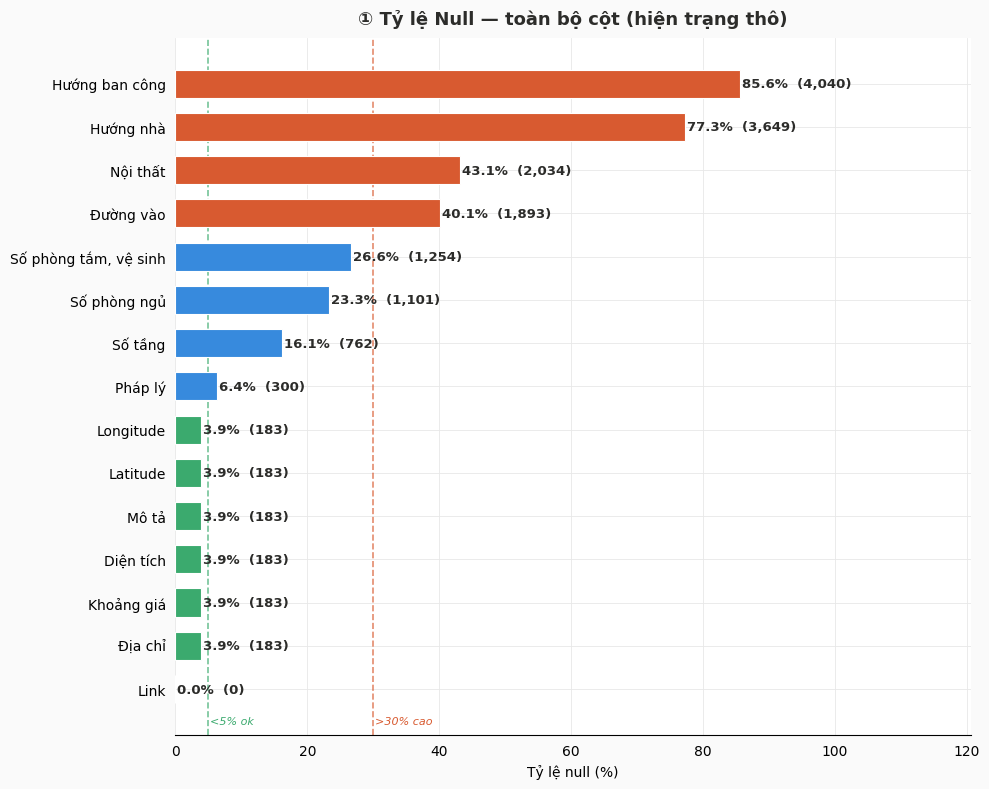

In [5]:
null_s   = _d.isnull().sum()
null_pct = _d.isnull().mean() * 100
null_df  = pd.DataFrame({'Null': null_s, 'Pct': null_pct}) \
             .query('Null >= 0') \
             .sort_values('Pct', ascending=True)

fig, ax1 = plt.subplots(figsize=(10, 8))

_nc = [C['green'] if v < 5 else C['blue'] if v < 30 else C['accent'] for v in null_df['Pct']]
bars1 = ax1.barh(null_df.index, null_df['Pct'], color=_nc, height=0.65, edgecolor='white', linewidth=0.8, zorder=3)

for bar, (col, row) in zip(bars1, null_df.iterrows()):
    ax1.text(row['Pct'] + 0.3, bar.get_y() + bar.get_height()/2,
             f"{row['Pct']:.1f}%  ({int(row['Null']):,})",
             va='center', fontsize=9.5, fontweight='bold', color=C['dark'])

ax1.axvline(5,  color=C['green'],  lw=1.2, ls='--', alpha=0.7)
ax1.axvline(30, color=C['accent'], lw=1.2, ls='--', alpha=0.7)
ax1.text(5.3,  -0.8, '<5% ok',   fontsize=8, color=C['green'],  style='italic')
ax1.text(30.3, -0.8, '>30% cao', fontsize=8, color=C['accent'], style='italic')

ax1.set_xlim(0, null_df['Pct'].max() * 1.35 + 5)
ax1.set_title('① Tỷ lệ Null — toàn bộ cột (hiện trạng thô)', fontsize=13, fontweight='bold', color=C['dark'], pad=10)
ax1.set_xlabel('Tỷ lệ null (%)', fontsize=10)
ax1.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


## CELL 2 — PHÂN BỐ KHOẢNG GIÁ

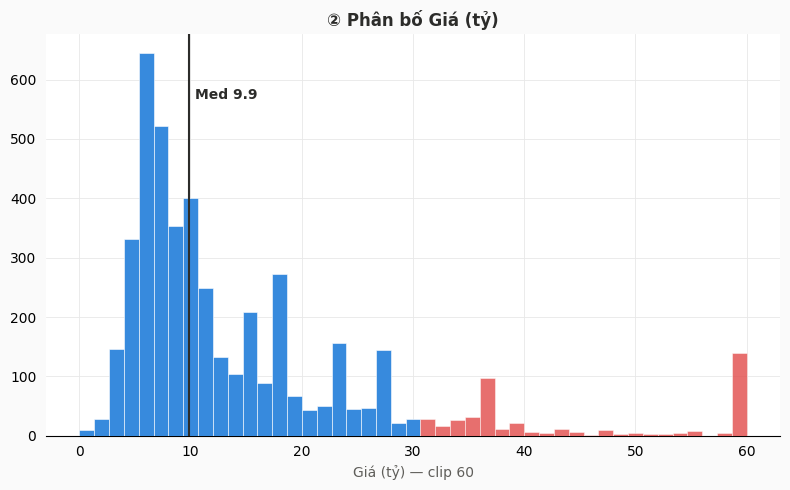

In [6]:
def _qprice(x):
    if pd.isna(x): return np.nan
    x = str(x).strip()
    x = x.replace('.', '').replace(',', '.')
    m = _re.search(r'([\d.]+)\s*(tỷ|triệu|tr)', x, _re.I)
    if not m: return np.nan
    v = float(m.group(1))
    return v if 'tỷ' in m.group(2).lower() else v / 1000

fig, ax2 = plt.subplots(figsize=(8, 5))

_prices = _d['Khoảng giá'].apply(_qprice).clip(upper=60).dropna()
n2, b2, p2 = ax2.hist(_prices, bins=45, color=C['blue'], edgecolor='white', linewidth=0.4, zorder=3)

for patch, left in zip(p2, b2[:-1]):
    if left >= 30: 
        patch.set_facecolor(C['red'])
        patch.set_alpha(0.8)

ax2.axvline(_prices.median(), color=C['dark'], lw=1.5, zorder=5)
ax2.text(_prices.median()+0.5, n2.max()*0.88,
         f"Med {_prices.median():.1f}", fontsize=10, color=C['dark'], fontweight='bold')

ax2.set_title('② Phân bố Giá (tỷ)', fontsize=12, fontweight='bold', color=C['dark'])
ax2.set_xlabel('Giá (tỷ) — clip 60', fontsize=10, color='#5F5E5A')
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

## CELL 3 — PHÂN BỐ DIỆN TÍCH

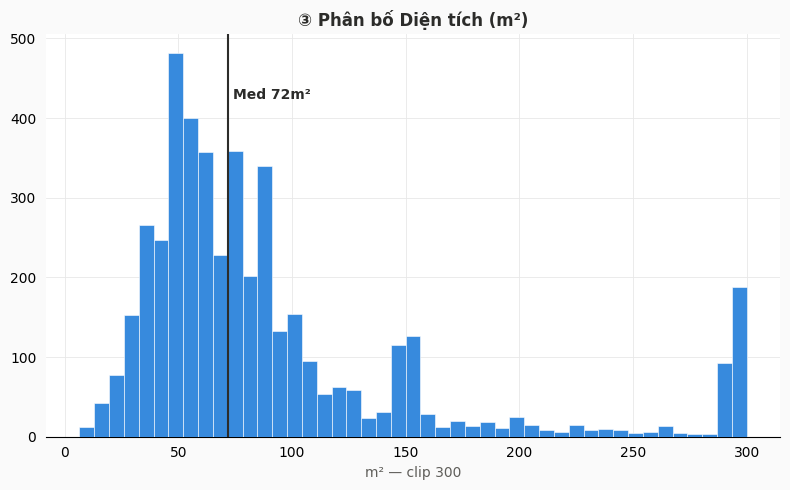

In [7]:
def _qarea(x):
    if pd.isna(x): return np.nan
    x = str(x).replace('.', '').replace(',', '.')
    m = _re.search(r'([\d.]+)', x)
    return float(m.group(1)) if m else np.nan

fig, ax3 = plt.subplots(figsize=(8, 5))

_areas = _d['Diện tích'].apply(_qarea).clip(upper=300).dropna()
n3, _, _ = ax3.hist(_areas, bins=45, color=C['blue'], edgecolor='white', linewidth=0.4, zorder=3)

ax3.axvline(_areas.median(), color=C['dark'], lw=1.5, zorder=5)
ax3.text(_areas.median()+2, n3.max()*0.88,
         f"Med {_areas.median():.0f}m²", fontsize=10, color=C['dark'], fontweight='bold')

ax3.set_title('③ Phân bố Diện tích (m²)', fontsize=12, fontweight='bold', color=C['dark'])
ax3.set_xlabel('m² — clip 300', fontsize=10, color='#5F5E5A')
ax3.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

## CELL 4 - Phân bố Pháp lý

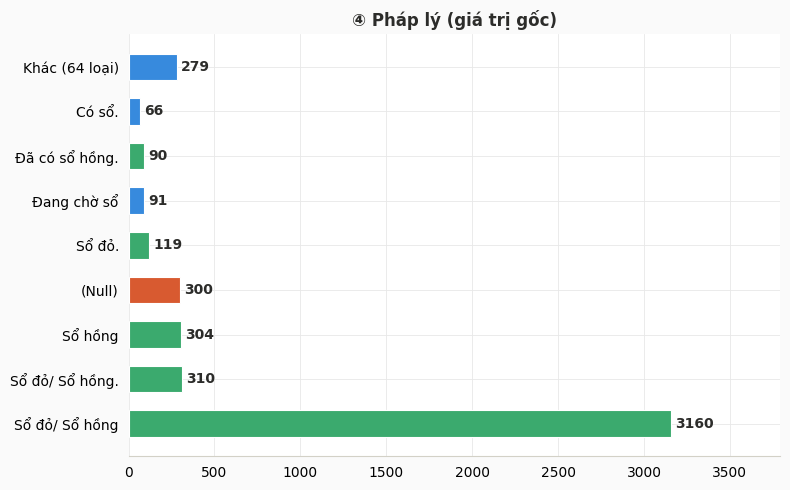

In [8]:
fig, ax4 = plt.subplots(figsize=(8, 5))

_legal = _truncate(_d['Pháp lý'], top_n=8, max_len=30)
_lc = [C['accent'] if '(Null)' in k else C['green'] if 'hồng' in k.lower() or 'đỏ' in k.lower() else C['blue'] for k in _legal.index]

bars4 = ax4.barh(_legal.index, _legal.values, color=_lc, height=0.6, edgecolor='white', linewidth=0.8, zorder=3)
ax4.bar_label(bars4, fmt='%d', padding=3, fontsize=10, color=C['dark'], fontweight='bold')

ax4.set_title('④ Pháp lý (giá trị gốc)', fontsize=12, fontweight='bold', color=C['dark'])
ax4.tick_params(labelsize=10)
ax4.set_xlim(0, _legal.values.max() * 1.2)
ax4.spines['bottom'].set_visible(True)
ax4.spines['bottom'].set_color('#D3D1C7')

plt.tight_layout()
plt.show()

## CELL 5 - Phân bố Phòng ngủ

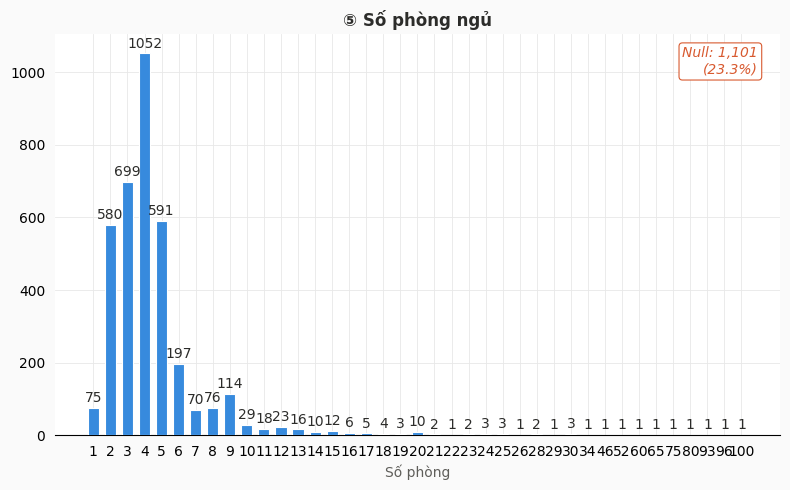

In [9]:
def _qint(x):
    m = _re.search(r'\d+', str(x))
    return int(m.group()) if m else np.nan

fig, ax5 = plt.subplots(figsize=(8, 5))

_beds = _d['Số phòng ngủ'].apply(_qint).dropna().astype(int)
_bed_cnt = _beds.value_counts().sort_index()

ax5.bar(_bed_cnt.index.astype(str), _bed_cnt.values, color=C['blue'], width=0.65, edgecolor='white', linewidth=0.8, zorder=3)
ax5.bar_label(ax5.containers[0], fmt='%d', padding=2, fontsize=10, color=C['dark'])

null5 = _d['Số phòng ngủ'].isnull().sum()
ax5.text(0.97, 0.97, f"Null: {null5:,}\n({null5/len(_d)*100:.1f}%)",
         transform=ax5.transAxes, ha='right', va='top', fontsize=10,
         color=C['accent'], style='italic',
         bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=C['accent'], lw=0.8))

ax5.set_title('⑤ Số phòng ngủ', fontsize=12, fontweight='bold', color=C['dark'])
ax5.set_xlabel('Số phòng', fontsize=10, color='#5F5E5A')
ax5.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

## Cell 6 - Phân bố Số tầng

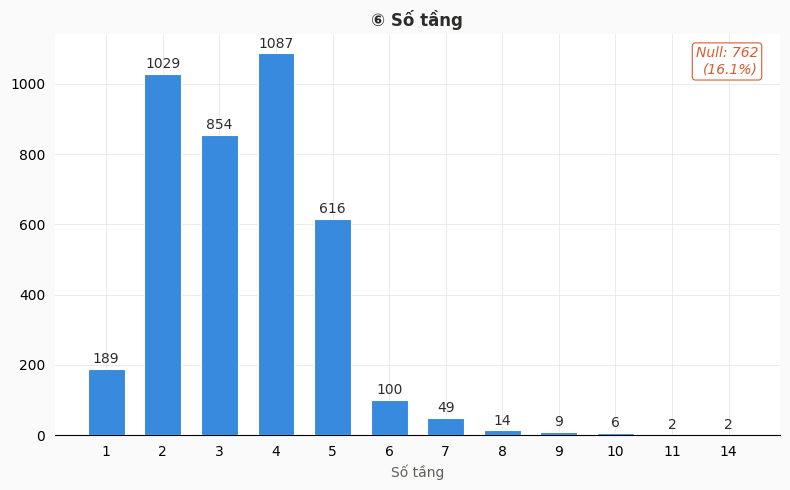

In [10]:
fig, ax6 = plt.subplots(figsize=(8, 5))

_floors = _d['Số tầng'].apply(_qint).dropna().astype(int)
_fl_cnt = _floors.value_counts().sort_index()

ax6.bar(_fl_cnt.index.astype(str), _fl_cnt.values, color=C['blue'], width=0.65, edgecolor='white', linewidth=0.8, zorder=3)
ax6.bar_label(ax6.containers[0], fmt='%d', padding=2, fontsize=10, color=C['dark'])

null6 = _d['Số tầng'].isnull().sum()
ax6.text(0.97, 0.97, f"Null: {null6:,}\n({null6/len(_d)*100:.1f}%)",
         transform=ax6.transAxes, ha='right', va='top', fontsize=10,
         color=C['accent'], style='italic',
         bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=C['accent'], lw=0.8))

ax6.set_title('⑥ Số tầng', fontsize=12, fontweight='bold', color=C['dark'])
ax6.set_xlabel('Số tầng', fontsize=10, color='#5F5E5A')
ax6.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

## Cell 7 - Phân bố Nội Thất

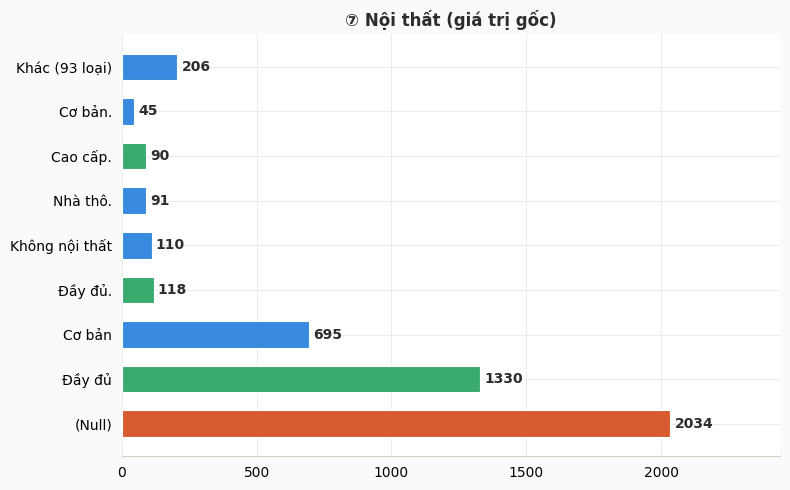

In [11]:
fig, ax7 = plt.subplots(figsize=(8, 5))

_furn = _truncate(_d['Nội thất'], top_n=8, max_len=30)
_fc = [C['accent'] if '(Null)' in k else C['green'] if 'đầy' in k.lower() or 'cao' in k.lower() else C['blue'] for k in _furn.index]

bars7 = ax7.barh(_furn.index, _furn.values, color=_fc, height=0.6, edgecolor='white', linewidth=0.8, zorder=3)
ax7.bar_label(bars7, fmt='%d', padding=3, fontsize=10, color=C['dark'], fontweight='bold')

ax7.set_title('⑦ Nội thất (giá trị gốc)', fontsize=12, fontweight='bold', color=C['dark'])
ax7.tick_params(labelsize=10)
ax7.set_xlim(0, _furn.values.max() * 1.2)
ax7.spines['bottom'].set_visible(True)
ax7.spines['bottom'].set_color('#D3D1C7')

plt.tight_layout()
plt.show()

## Cell 8 - Phân bố Đường vào

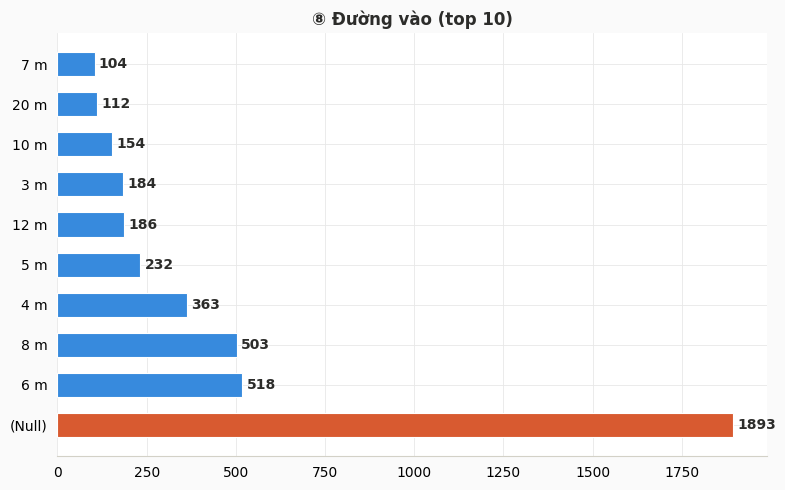

In [12]:
fig, ax8 = plt.subplots(figsize=(8, 5))

_road = _d['Đường vào'].fillna('(Null)').value_counts().head(10)
_rc = [C['accent'] if k=='(Null)' else C['blue'] for k in _road.index]

bars8 = ax8.barh(_road.index, _road.values, color=_rc, height=0.6, edgecolor='white', linewidth=0.8, zorder=3)
ax8.bar_label(bars8, fmt='%d', padding=3, fontsize=10, color=C['dark'], fontweight='bold')

ax8.set_title('⑧ Đường vào (top 10)', fontsize=12, fontweight='bold', color=C['dark'])
ax8.tick_params(labelsize=10)
ax8.spines['bottom'].set_visible(True)
ax8.spines['bottom'].set_color('#D3D1C7')

plt.tight_layout()
plt.show()

## Cell 9 - Phân bố Hướng nhà

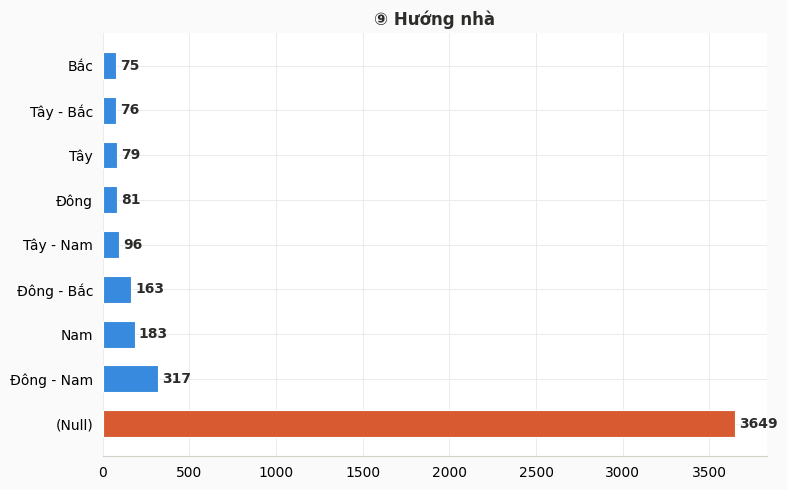

In [13]:
fig, ax9 = plt.subplots(figsize=(8, 5))

_dir = _d['Hướng nhà'].fillna('(Null)').value_counts()
_dc = [C['accent'] if k=='(Null)' else C['blue'] for k in _dir.index]

bars9 = ax9.barh(_dir.index, _dir.values, color=_dc, height=0.6, edgecolor='white', linewidth=0.8, zorder=3)
ax9.bar_label(bars9, fmt='%d', padding=3, fontsize=10, color=C['dark'], fontweight='bold')

ax9.set_title('⑨ Hướng nhà', fontsize=12, fontweight='bold', color=C['dark'])
ax9.tick_params(labelsize=10)
ax9.spines['bottom'].set_visible(True)
ax9.spines['bottom'].set_color('#D3D1C7')

plt.tight_layout()
plt.show()

## Cell 10 - Phân bố Địa lý

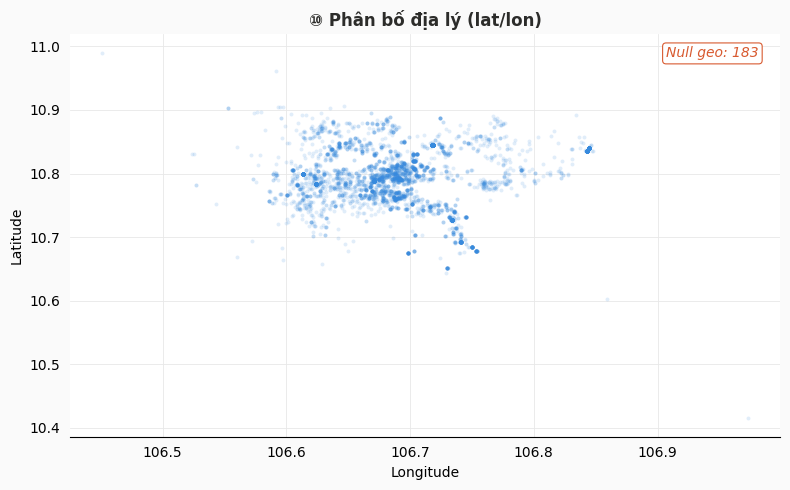

In [14]:
fig, ax10 = plt.subplots(figsize=(8, 5))

_geo = _d[['Latitude','Longitude']].dropna()
_geo = _geo[_geo['Latitude'].between(10.4, 11.2) & _geo['Longitude'].between(106.3, 107.1)]

ax10.scatter(_geo['Longitude'], _geo['Latitude'], alpha=0.15, s=8, color=C['blue'], linewidths=0, zorder=3)

null_geo = _d[['Latitude','Longitude']].isnull().any(axis=1).sum()
ax10.text(0.97, 0.97, f"Null geo: {null_geo:,}",
          transform=ax10.transAxes, ha='right', va='top', fontsize=10,
          color=C['accent'], style='italic',
          bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=C['accent'], lw=0.8))

ax10.set_title('⑩ Phân bố địa lý (lat/lon)', fontsize=12, fontweight='bold', color=C['dark'])
ax10.set_xlabel('Longitude', fontsize=10)
ax10.set_ylabel('Latitude', fontsize=10)
ax10.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# 3.2 EDA sau tiền xử lý

In [15]:
# Cell load Cleaned_data.csv
file_path = CLEANED_DIR / "Cleaned_data.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')
print(' Load dữ liệu thành công!')
display(df.head())

 Load dữ liệu thành công!


,Link,Địa chỉ,Diện tích,Số phòng ngủ,"Số phòng tắm, vệ sinh",Số tầng,Đường vào,Pháp lý,Nội thất,Latitude,Longitude,Mô tả,Loại đường vào,Đường,Phường/Xã,Quận,loai_duong_null_flag,duong_vao_null_flag,Khoảng giá,Loại_Dữ_Liệu
0,https://batdongsan.com.vn/ban-nha-biet-thu-lie...,"The Manhattan Glory - Vinhomes Grand Park, Đườ...",200.0,8,8,3,NaN,Sổ đỏ,Trống / Nhà thô,10.835634,106.842917,"Bán biệt thự khu compound an ninh, số lượng că...",Chưa xác định,Nguyễn Xiển,Long Bình,9,1,1,28.00,Train
1,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"Đường Thạnh Lộc 16, Phường An Phú Đông, Quận 1...",51.0,4,4,4,8.0,Sổ hồng,Cơ bản,10.850190,106.694991,Bất động sản Hoàng Gia Phát.\nGiá bán: 5 tỷ 85...,Chưa xác định,Thạnh Lộc 16,An Phú Đông,12,1,0,5.85,Train
2,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"Đường Cách Mạng Tháng Tám, Phường 5, Quận Tân ...",62.0,1,1,1,10.0,Sổ hồng,Trống / Nhà thô,10.788522,106.661350,- Nhà có vị trí cực đẹp gần nhà thờ giáo xứ Th...,Chưa xác định,Cách Mạng Tháng Tám,5,Tân Bình,1,0,10.90,Train
3,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"Đường Nguyễn Hồng Đào, Phường 14, Quận Tân Bìn...",106.0,3,3,2,6.0,Sổ hồng,Đầy đủ,10.795538,106.642995,Chính Chủ thiện chí bán nhà hẻm xe hơi 6m Đườn...,Mặt tiền,Nguyễn Hồng Đào,14,Tân Bình,0,0,12.80,Train
4,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"Đường Lê Quang Định, Phường 11, Quận Bình Thạn...",58.0,4,4,4,6.0,Sổ hồng,Đầy đủ,10.813389,106.689892,"Bán nhà Lê Quang Định, P. Bình Lợi Trung (P.11...",Chưa xác định,Lê Quang Định,11,Bình Thạnh,1,0,9.50,Train


In [16]:
import pandas as pd


print("1. Số lượng listing và số cột (Dòng, Cột):")
print(df.shape) 
print("\n2. Kiểu dữ liệu của từng cột:")
print(df.dtypes)

key_cols = ['Khoảng giá', 'Diện tích', 'Số phòng ngủ', 'Quận']

print("\n3. Thống kê mô tả các cột cốt lõi:")
print(df[key_cols].describe(include='all'))

print("\n4. Tỷ lệ Missing value của tất cả các cột (%):")
missing_pct = df.isnull().mean() * 100
print(missing_pct.sort_values(ascending=False))

print("\n🚨 KẾT LUẬN: Các cột bị thiếu dữ liệu nghiêm trọng (>30%):")
severe_missing = missing_pct[missing_pct > 30]

if not severe_missing.empty:
    print(severe_missing.sort_values(ascending=False))
    print("-> Hành động: Chỉ ghi nhận, chưa vội vá (impute) các cột này.")
else:
    print("-> Thật tuyệt! Không có cột nào bị thiếu trên 30% dữ liệu.")

1. Số lượng listing và số cột (Dòng, Cột):
(3512, 20)

2. Kiểu dữ liệu của từng cột:
Link                         str
Địa chỉ                      str
Diện tích                float64
Số phòng ngủ               int64
Số phòng tắm, vệ sinh      int64
Số tầng                    int64
Đường vào                float64
Pháp lý                      str
Nội thất                     str
Latitude                 float64
Longitude                float64
Mô tả                        str
Loại đường vào               str
Đường                        str
Phường/Xã                    str
Quận                         str
loai_duong_null_flag       int64
duong_vao_null_flag        int64
Khoảng giá               float64
Loại_Dữ_Liệu                 str
dtype: object

3. Thống kê mô tả các cột cốt lõi:
         Khoảng giá    Diện tích  Số phòng ngủ        Quận
count   3512.000000  3512.000000   3512.000000        3512
unique          NaN          NaN           NaN          24
top             NaN         

In [17]:
nan_percentage = (df.isnull().mean() * 100).round(2)

nan_percentage_sorted = nan_percentage.sort_values(ascending=False)

print("Tỷ lệ % NaN ở mỗi cột (sắp xếp giảm dần):")
print(nan_percentage_sorted)


Tỷ lệ % NaN ở mỗi cột (sắp xếp giảm dần):
Đường vào                33.94
Đường                     5.30
Link                      0.00
Địa chỉ                   0.00
Số phòng ngủ              0.00
Diện tích                 0.00
Số tầng                   0.00
Số phòng tắm, vệ sinh     0.00
Nội thất                  0.00
Latitude                  0.00
Longitude                 0.00
Pháp lý                   0.00
Mô tả                     0.00
Loại đường vào            0.00
Phường/Xã                 0.00
Quận                      0.00
loai_duong_null_flag      0.00
duong_vao_null_flag       0.00
Khoảng giá                0.00
Loại_Dữ_Liệu              0.00
dtype: float64


## Bussiness EDA

**Overall Insights**

 Mức giá trung bình tổng thể có sự phân hóa cực kỳ rõ rệt giữa các nhóm tài sản, cho thấy cấu trúc định giá phụ thuộc rất lớn vào vị trí địa lý lõi và khả năng tiếp cận giao thông.

 Mức độ tập trung giá trị đã phân hóa rõ rệt giữa các Khu vực (Quận/Huyện):

- Nhóm trung tâm: Quận 3 và Quận 1 có mức định giá trung bình cao nhất (đạt trên 41 - 45 tỷ VND).

- Nhóm ngoại thành: Củ Chi, Hóc Môn trở thành nhóm có giá trị thấp nhất, trong khi các khu vực vùng ven khác như Quận 9, Bình Tân duy trì ở phân khúc trung bình.

 Các Loại đường vào (Entrance Types) có giá trị cao phân cấp theo mức độ tiếp cận:

- Nhóm tiếp cận tốt: Bất động sản "Mặt tiền" có mức giá cao vượt trội nhất (trung bình ~21.5 tỷ VND).

- Nhóm tiếp cận hạn chế: "Hẻm ô tô" và "Hẻm xe máy" trở thành các nhóm có mức giá thấp hơn hẳn (dao động từ 8 đến 10 tỷ VND).

 Đặc tính "Mặt tiền" liên tục duy trì là một yếu tố cấu thành giá trị (premium) cao mang tính quyết định trong toàn bộ bộ dữ liệu.

 Các bất động sản quy mô diện tích lớn (large-sized properties) liên tục có mức định giá cao vượt trội (~32.9 tỷ VND) so với các nhà quy mô trung bình (~11.1 tỷ VND) và nhỏ (~8.1 tỷ VND), cho thấy đây là một mẫu định giá mang tính cấu trúc và ổn định.

 Các bất động sản tại trung tâm kinh tế (central locations) luôn duy trì định giá cao nhất, cho thấy các tài sản tại khu vực lõi dễ đạt mức giá "premium" hơn.

 Một số tổ hợp giữa Quận – Loại đường vào cho thấy mức giá cực kỳ cao (lên tới trung bình 59.2 tỷ VND cho tổ hợp Quận 3 - Mặt tiền và 48 tỷ VND cho Quận 1 - Mặt tiền), có thể phản ánh sự khan hiếm nguồn cung cốt lõi hoặc giá trị khai thác thương mại đắc địa.

 DIỆN TÍCH (Area) và ĐƯỜNG VÀO (Entrance Width) dường như là các biến dự báo mạnh về giá trị tài sản do có hệ số tương quan cao nhất và có sự khác biệt phân phối rõ rệt giữa các phân khúc giá.
 SỐ PHÒNG NGỦ (Bedrooms) và SỐ TẦNG (Floors) cho thấy mức độ dự báo trung bình đối với sự biến động giá.
 TỌA ĐỘ (Latitude & Longitude) liên tục cho thấy khả năng dự báo yếu (hệ số tương quan gần 0), cho thấy các biến này có giá trị phân loại hạn chế nếu đứng độc lập mà không đối chiếu với nhãn khu vực (Quận/Phường).

 Mặc dù quy mô diện tích đóng vai trò quan trọng trong việc nâng cao giá trị tài sản, các yếu tố cấu trúc cốt lõi định hình giá nhà nhìn chung vẫn xoay quanh sự nhất quán của "Vị trí trung tâm" và "Loại đường tiếp cận".

> Các biểu đồ được thiết kế theo các hướng insight trong báo cáo tham khảo, nhưng kết luận được tính lại từ dữ liệu **sau tiền xử lý**.

--- PHÂN TÍCH BIẾN MỤC TIÊU: KHOẢNG GIÁ ---
✅ Không có giá trị giá <= 0.

1. Thống kê chi tiết (Percentiles):
count    3512.00
mean       17.48
std        35.21
min         1.05
5%          4.12
25%         6.50
50%         9.12
75%        16.90
95%        46.45
max       700.00
Name: Khoảng giá, dtype: float64

2. Độ lệch (Skewness) của giá gốc: 9.79
   -> Đánh giá: Dữ liệu lệch phải RẤT NẶNG. Rất cần thiết phải Log Transform.


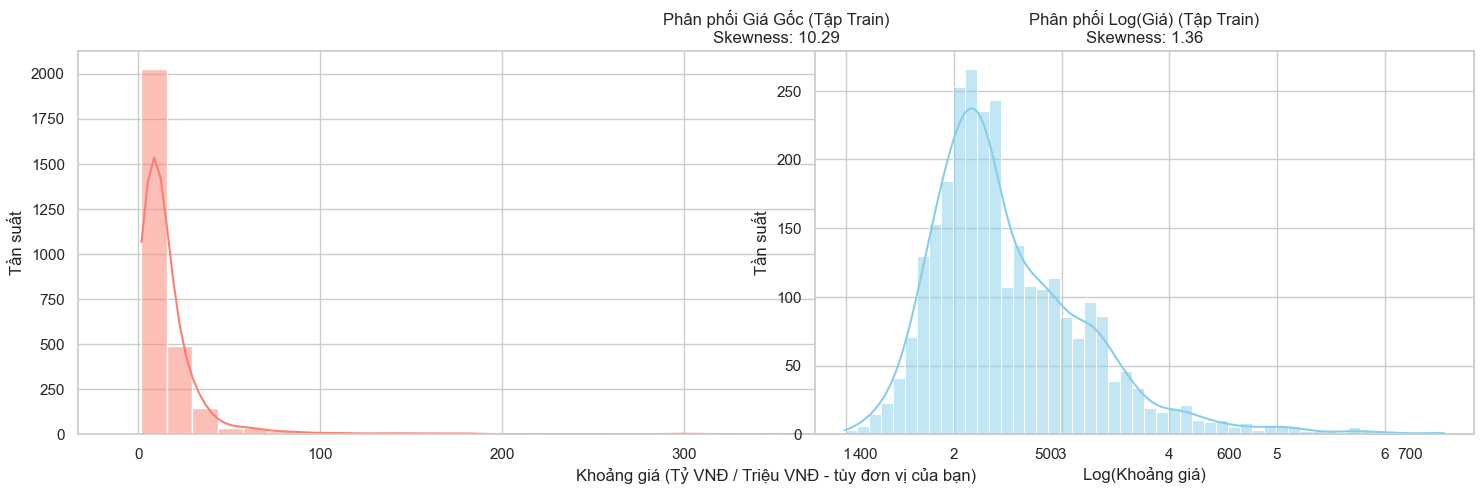

In [18]:
print("--- PHÂN TÍCH BIẾN MỤC TIÊU: KHOẢNG GIÁ ---")

invalid_prices = df[df['Khoảng giá'] <= 0]
if not invalid_prices.empty:
    print(f"⚠️ CẢNH BÁO: Phát hiện {len(invalid_prices)} dòng có giá <= 0. Cần xử lý trước khi log transform!")
    df_analysis = df[df['Khoảng giá'] > 0].copy()
else:
    print("✅ Không có giá trị giá <= 0.")
    df_analysis = df.copy()

print("\n1. Thống kê chi tiết (Percentiles):")
print(df_analysis['Khoảng giá'].describe(percentiles=[.05, .25, .5, .75, .95]).round(2))

skewness_original = df_analysis['Khoảng giá'].skew()
print(f"\n2. Độ lệch (Skewness) của giá gốc: {skewness_original:.2f}")

if skewness_original > 1.5:
    print("   -> Đánh giá: Dữ liệu lệch phải RẤT NẶNG. Rất cần thiết phải Log Transform.")
elif skewness_original > 0:
    print("   -> Đánh giá: Dữ liệu lệch phải vừa phải.")
else:
    print("   -> Đánh giá: Dữ liệu không bị lệch phải.")

df_analysis['Log_Khoảng_giá'] = np.log1p(df_analysis['Khoảng giá'])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

train_data = df_analysis[df_analysis['Loại_Dữ_Liệu'] == 'Train']

sns.histplot(train_data['Khoảng giá'], kde=True, bins=50, color='salmon')
plt.title(f'Phân phối Giá Gốc (Tập Train)\nSkewness: {train_data["Khoảng giá"].skew():.2f}')
plt.xlabel('Khoảng giá (Tỷ VNĐ / Triệu VNĐ - tùy đơn vị của bạn)')
plt.ylabel('Tần suất')

plt.subplot(1, 2, 2)
sns.histplot(train_data['Log_Khoảng_giá'], kde=True, bins=50, color='skyblue')
plt.title(f'Phân phối Log(Giá) (Tập Train)\nSkewness: {train_data["Log_Khoảng_giá"].skew():.2f}')
plt.xlabel('Log(Khoảng giá)')
plt.ylabel('Tần suất')

plt.tight_layout()
plt.show()

- Skewness 9.84 → phân phối gốc lệch cực nặng — đúng với thị trường BĐS thực tế, thiểu số nhà siêu sang kéo đuôi phải rất xa
- Log transform kéo skewness xuống 1.43

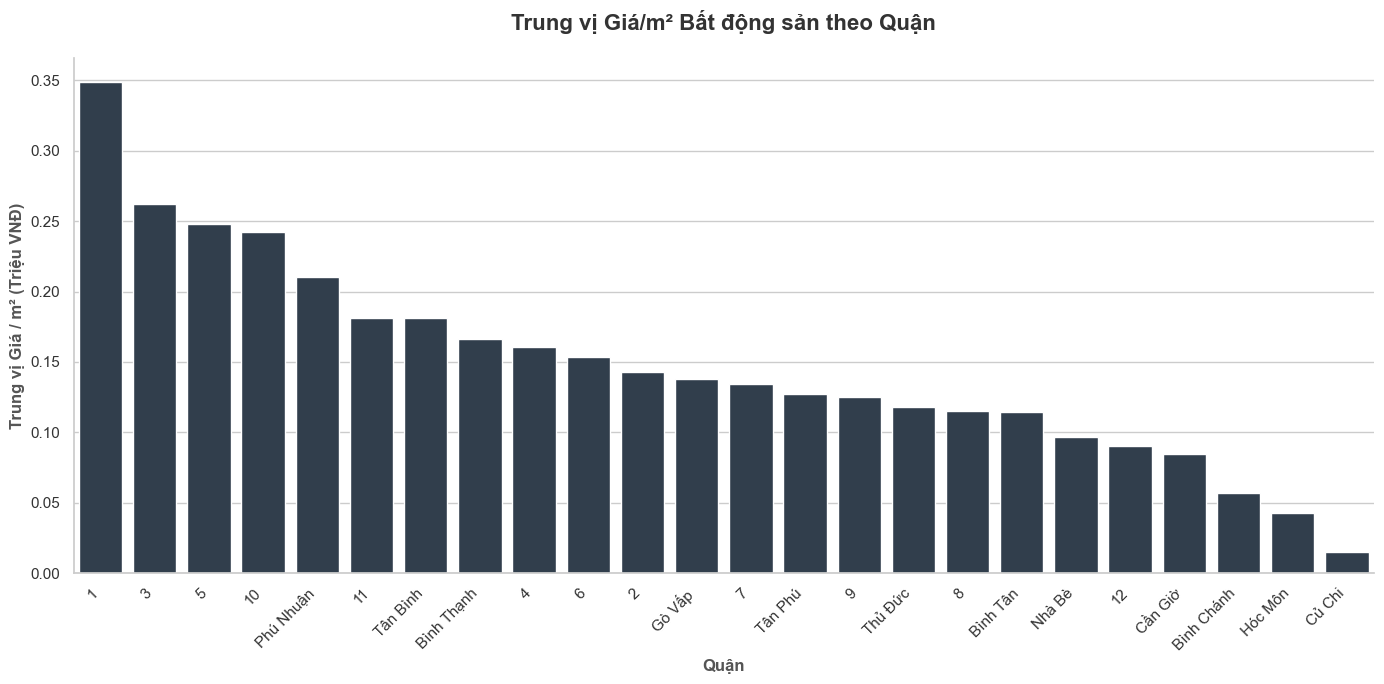

In [19]:
if 'Giá_trên_m2' not in df.columns:
    df['Giá_trên_m2'] = df['Khoảng giá'] / df['Diện tích'].replace(0, np.nan)

df_plot = df.dropna(subset=['Giá_trên_m2', 'Quận']).copy()

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.figure(figsize=(14, 7))

thu_tu_quan = df_plot.groupby('Quận')['Giá_trên_m2'].median().sort_values(ascending=False).index

sns.barplot(
    data=df_plot, 
    x='Quận', 
    y='Giá_trên_m2', 
    order=thu_tu_quan, 
    estimator=np.median, 
    errorbar=None, 
    color='#2c3e50' 
)

plt.title('Trung vị Giá/m² Bất động sản theo Quận', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Quận', fontsize=12, fontweight='bold', color='#555555')
plt.ylabel('Trung vị Giá / m² (Triệu VNĐ)', fontsize=12, fontweight='bold', color='#555555')

plt.xticks(rotation=45, ha='right', fontsize=11, color='#333333')
plt.yticks(fontsize=11, color='#333333')

plt.tight_layout()
plt.show()

- Gradient rõ ràng từ trung tâm → ngoại thành: Q1 (0.34) → Củ Chi (0.014), chênh lệch ~24x → location premium là yếu tố định giá số 1
- Q3 vượt Q5, Q7: bất ngờ hợp lý — Q3 có mặt tiền trục lớn, gần Q1, diện tích nhỏ nên giá/m² cao
- Nhà Bè, Bình Chánh, Hóc Môn <0.1 → vùng đệm, phù hợp đầu tư dài hạn chờ quy hoạch, không phù hợp lướt sóng ngắn hạn

--- KIỂM TRA ĐỘ TIN CẬY CỦA DỮ LIỆU THEO KHU VỰC ---
⚠️ CẢNH BÁO: Có 5 quận/huyện có dưới 30 listings.
Danh sách và số lượng chi tiết:
Quận
Bình Chánh    28
Hóc Môn       27
4             25
Cần Giờ        4
Củ Chi         2
Name: count, dtype: int64
-> Hướng xử lý sau EDA: Cân nhắc gộp các quận này thành nhóm 'Khác' (Other) hoặc gộp theo vùng (ví dụ: 'Vùng Ven') để mô hình học tốt hơn.


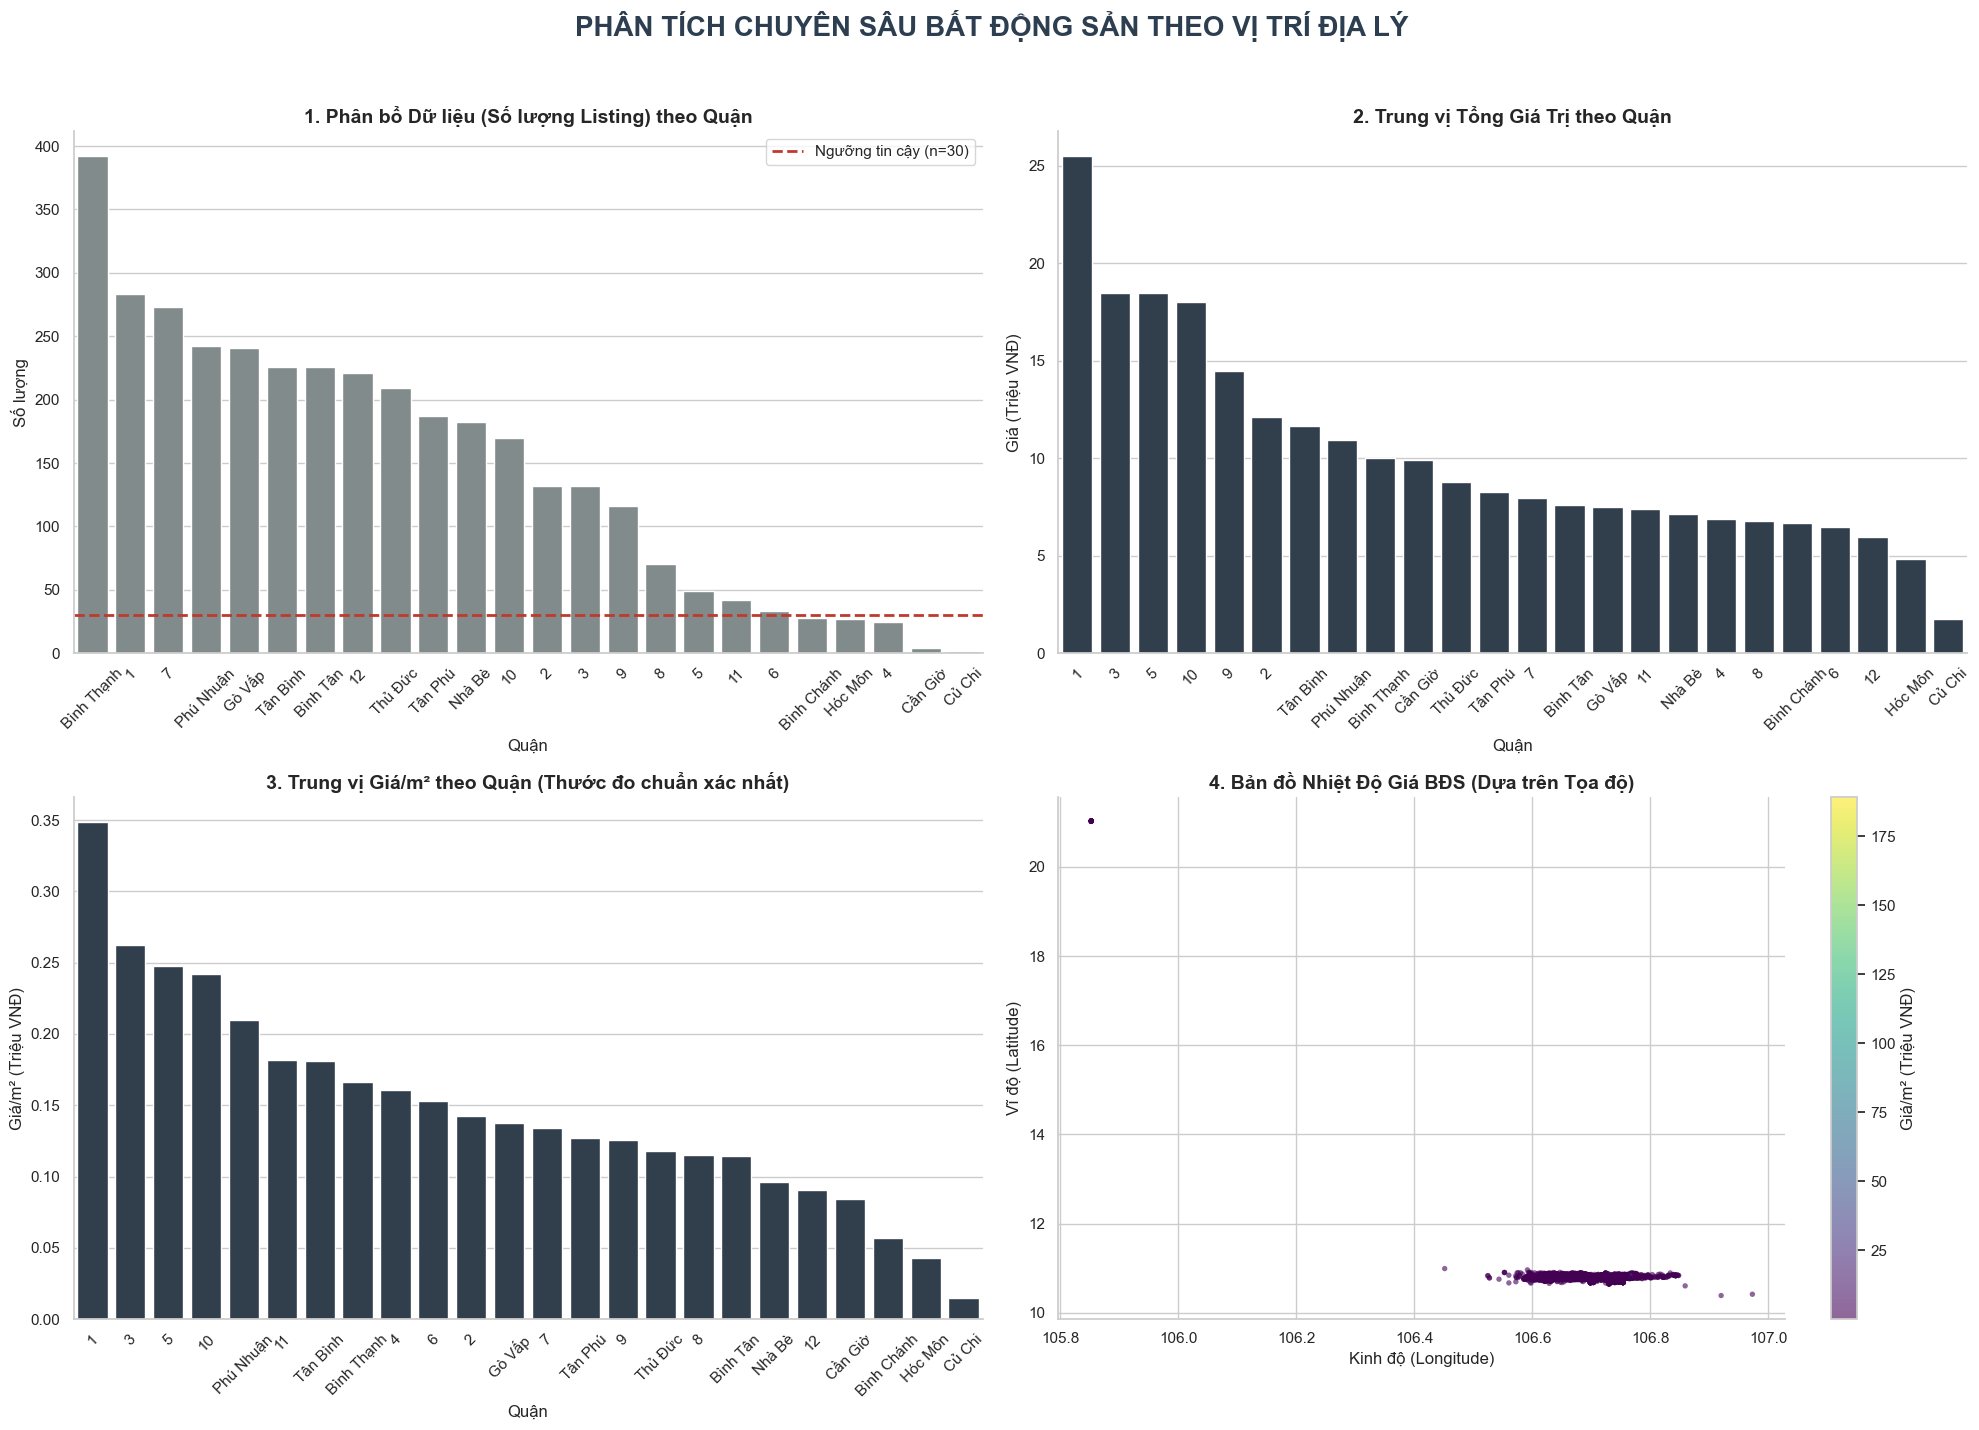

In [20]:
print("--- KIỂM TRA ĐỘ TIN CẬY CỦA DỮ LIỆU THEO KHU VỰC ---")

count_by_district = df['Quận'].value_counts()

quan_it_du_lieu = count_by_district[count_by_district < 30]

if not quan_it_du_lieu.empty:
    print(f"⚠️ CẢNH BÁO: Có {len(quan_it_du_lieu)} quận/huyện có dưới 30 listings.")
    print("Danh sách và số lượng chi tiết:")
    print(quan_it_du_lieu)
    print("-> Hướng xử lý sau EDA: Cân nhắc gộp các quận này thành nhóm 'Khác' (Other) "
          "hoặc gộp theo vùng (ví dụ: 'Vùng Ven') để mô hình học tốt hơn.")
else:
    print("✅ Tuyệt vời! Tất cả các quận đều có số lượng mẫu >= 30, đảm bảo độ tin cậy thống kê.")

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('PHÂN TÍCH CHUYÊN SÂU BẤT ĐỘNG SẢN THEO VỊ TRÍ ĐỊA LÝ', fontsize=20, fontweight='bold', color='#2c3e50', y=1.02)

primary_color = '#2c3e50'
secondary_color = '#7f8c8d'

order_count = count_by_district.index
sns.barplot(x=order_count, y=count_by_district.values, ax=axes[0, 0], color=secondary_color)
axes[0, 0].set_title('1. Phân bổ Dữ liệu (Số lượng Listing) theo Quận', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Số lượng', fontsize=12)
axes[0, 0].axhline(30, color='#c0392b', linestyle='--', linewidth=2, label='Ngưỡng tin cậy (n=30)')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

order_price = df.groupby('Quận')['Khoảng giá'].median().sort_values(ascending=False).index
sns.barplot(data=df, x='Quận', y='Khoảng giá', order=order_price, estimator=np.median, errorbar=None, ax=axes[0, 1], color=primary_color)
axes[0, 1].set_title('2. Trung vị Tổng Giá Trị theo Quận', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Giá (Triệu VNĐ)', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)

order_sqm = df.groupby('Quận')['Giá_trên_m2'].median().sort_values(ascending=False).index
sns.barplot(data=df, x='Quận', y='Giá_trên_m2', order=order_sqm, estimator=np.median, errorbar=None, ax=axes[1, 0], color=primary_color)
axes[1, 0].set_title('3. Trung vị Giá/m² theo Quận (Thước đo chuẩn xác nhất)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Giá/m² (Triệu VNĐ)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)

if 'Latitude' in df.columns and 'Longitude' in df.columns:
    df_geo = df.dropna(subset=['Latitude', 'Longitude', 'Giá_trên_m2'])
    
    df_geo = df_geo[(df_geo['Latitude'] > 8) & (df_geo['Latitude'] < 24) & 
                    (df_geo['Longitude'] > 102) & (df_geo['Longitude'] < 110)]
    
    scatter = axes[1, 1].scatter(
        df_geo['Longitude'], df_geo['Latitude'], 
        c=df_geo['Giá_trên_m2'], cmap='viridis',
        alpha=0.6, s=15, edgecolors='none'
    )
    axes[1, 1].set_title('4. Bản đồ Nhiệt Độ Giá BĐS (Dựa trên Tọa độ)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Kinh độ (Longitude)', fontsize=12)
    axes[1, 1].set_ylabel('Vĩ độ (Latitude)', fontsize=12)
    
    cbar = fig.colorbar(scatter, ax=axes[1, 1])
    cbar.set_label('Giá/m² (Triệu VNĐ)')
else:
    axes[1, 1].text(0.5, 0.5, "Không có dữ liệu Tọa độ\n(Latitude/Longitude)", 
                    horizontalalignment='center', verticalalignment='center', fontsize=14, color='gray')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

1. Chart 1 — Phân bố listing:

- Bình Thạnh, Q1, Q7 dẫn đầu → nguồn cung lớn, thị trường sôi động
- Củ Chi, Hóc Môn, Cần Giờ dưới ngưỡng n=30 → không đủ tin cậy để phân tích thống kê

2. Chart 2 — Tổng giá trị trung vị:

- Q1 bỏ xa (~21 tỷ) → absolute price cao nhất, phản ánh quỹ đất khan hiếm
- Củ Chi ~2 tỷ → chênh lệch 10x so với Q1, minh chứng rõ gradient vị trí

3. Chart 3 — Giá/m² (đáng tin cậy nhất):

- Q1 (~0.34) > Q3, Q10 (~0.26–0.24) → core districts giữ premium bền vững
- Củ Chi ~0.01 → giá/m² gần như không có premium, đất nền thuần túy
- Thứ tự này khác chart 2 → Q10 nổi lên khi normalize theo m², cho thấy nhà Q10 diện tích nhỏ nhưng đắt/m²

4. Chart 4 — Heatmap tọa độ:

- Cluster dày đặc quanh 106.6–106.8 longitude → lõi đô thị TP.HCM

--- PHÂN TÍCH ĐẶC ĐIỂM BẤT ĐỘNG SẢN VS GIÁ ---


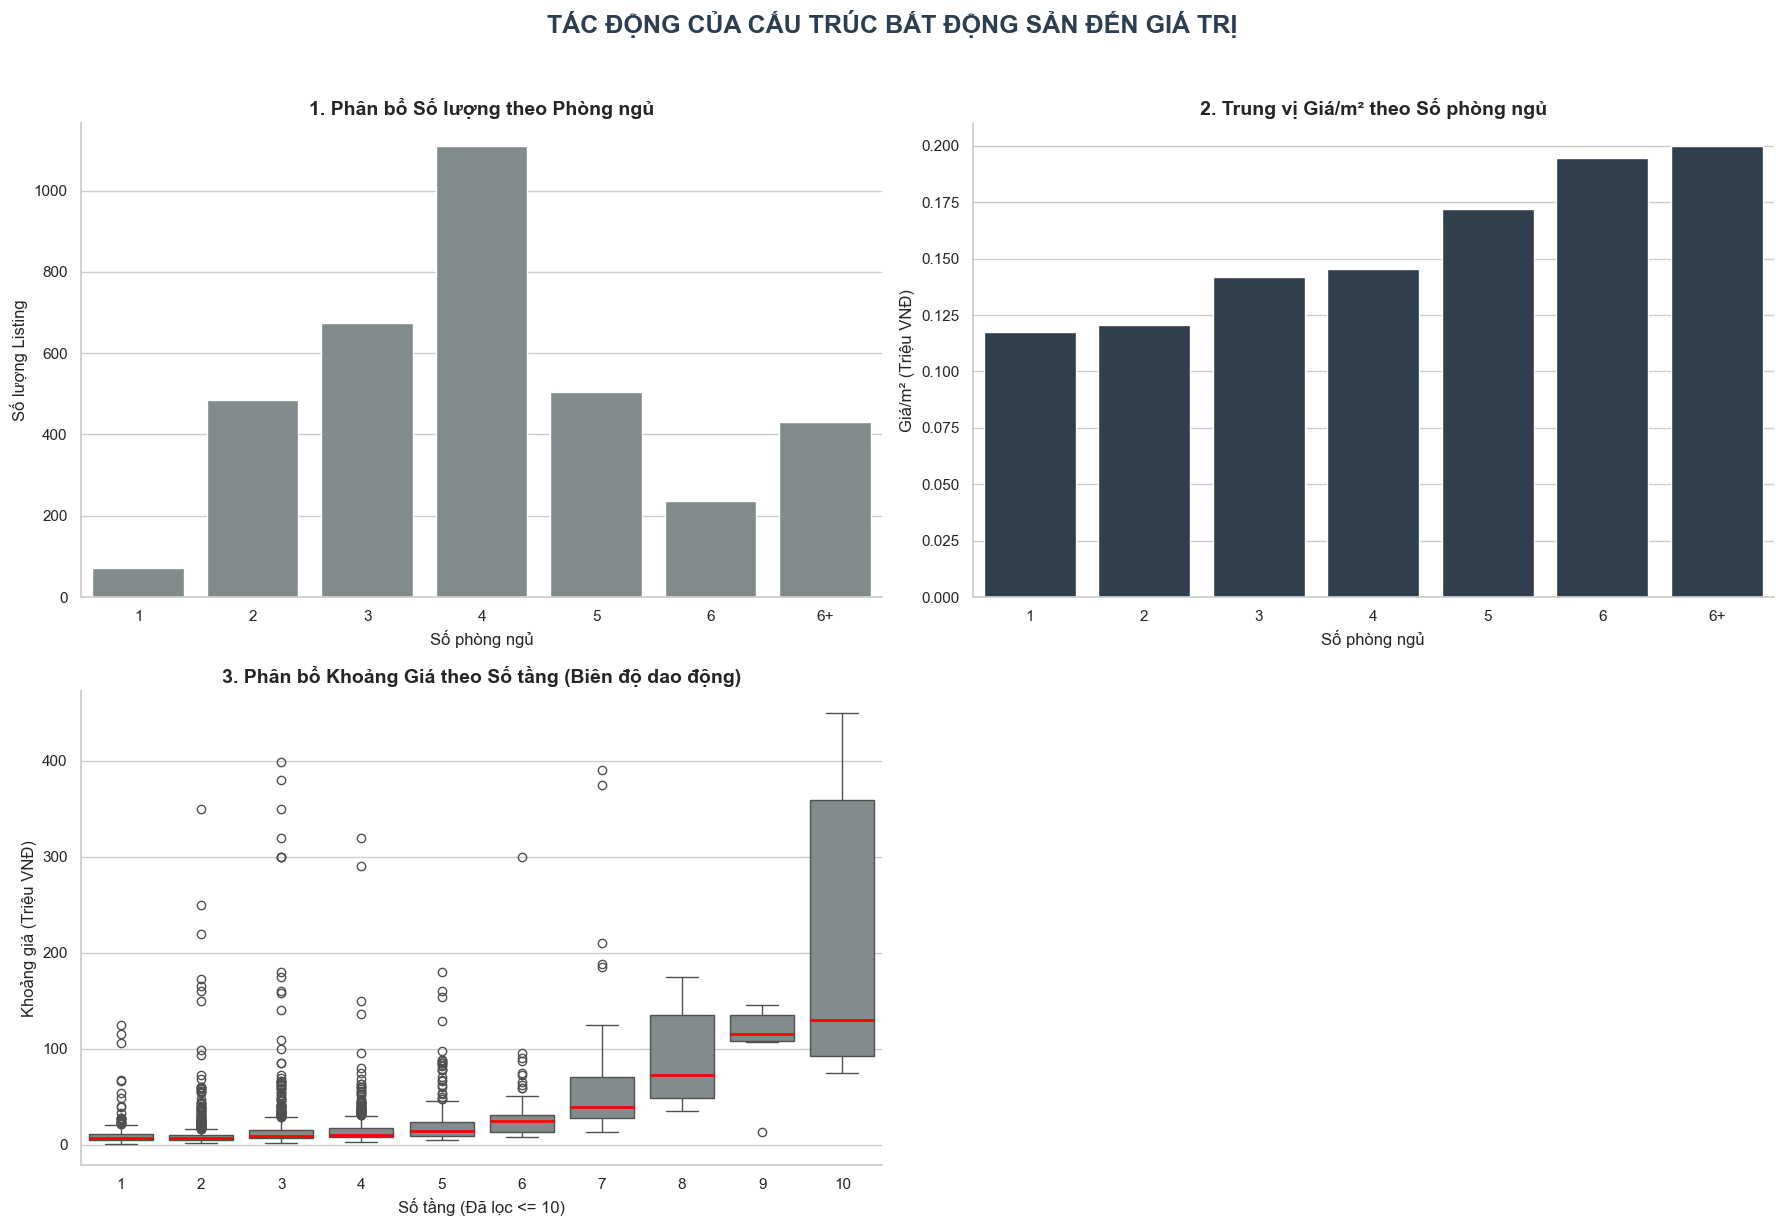

In [21]:
print("--- PHÂN TÍCH ĐẶC ĐIỂM BẤT ĐỘNG SẢN VS GIÁ ---")

df_plot = df.copy()
df_plot['Nhóm_Phòng_Ngủ'] = df_plot['Số phòng ngủ'].apply(
    lambda x: '6+' if pd.notnull(x) and x > 6 else str(int(x)) if pd.notnull(x) else 'NaN'
)

order_pn = ['1', '2', '3', '4', '5', '6', '6+']

df_floor_plot = df_plot[(df_plot['Số tầng'].notnull()) & (df_plot['Số tầng'] <= 10)]

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
primary_color = '#2c3e50'
secondary_color = '#7f8c8d'

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('TÁC ĐỘNG CỦA CẤU TRÚC BẤT ĐỘNG SẢN ĐẾN GIÁ TRỊ', fontsize=18, fontweight='bold', color='#2c3e50', y=1.02)

sns.countplot(data=df_plot, x='Nhóm_Phòng_Ngủ', order=order_pn, color=secondary_color, ax=axes[0, 0])
axes[0, 0].set_title('1. Phân bổ Số lượng theo Phòng ngủ', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Số phòng ngủ', fontsize=12)
axes[0, 0].set_ylabel('Số lượng Listing', fontsize=12)

sns.barplot(data=df_plot, x='Nhóm_Phòng_Ngủ', y='Giá_trên_m2', order=order_pn, 
            estimator=np.median, errorbar=None, color=primary_color, ax=axes[0, 1])
axes[0, 1].set_title('2. Trung vị Giá/m² theo Số phòng ngủ', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Số phòng ngủ', fontsize=12)
axes[0, 1].set_ylabel('Giá/m² (Triệu VNĐ)', fontsize=12)

sns.boxplot(data=df_floor_plot, x='Số tầng', y='Khoảng giá', 
            color=secondary_color, medianprops={"color": "red", "linewidth": 2}, ax=axes[1, 0])
axes[1, 0].set_title('3. Phân bổ Khoảng Giá theo Số tầng (Biên độ dao động)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Số tầng (Đã lọc <= 10)', fontsize=12)
axes[1, 0].set_ylabel('Khoảng giá (Triệu VNĐ)', fontsize=12)


axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

1. Chart 1 — Phân bố theo phòng ngủ:

- 4PN chiếm đỉnh (~1200 listing) → phân khúc nhà phố tiêu chuẩn tại TP.HCM, nguồn cung dồi dào nhất
- 6+ PN cao bất thường hơn 6PN → khả năng nhà phố cũ nhiều phòng nhỏ bị gom vào bucket này

2. Chart 2 — Giá/m² theo phòng ngủ:

- Tương quan thuận rõ: càng nhiều phòng → giá/m² càng cao
- 1PN vs 2PN gần bằng nhau (~0.12) → anomaly, có thể 1PN là studio nhỏ vị trí tốt bị offset bởi 2PN diện tích lớn hơn
- 5–6+ PN đạt ~0.2 → nhà lớn thường ở mặt tiền/vị trí đắc địa, premium vị trí lấn át yếu tố diện tích

3. Chart 3 — Khoảng giá theo số tầng:

- Nhà 10 tầng có IQR cực rộng → phân khúc siêu không đồng nhất (mini building vs nhà phố cao tầng)
- Tầng 1–6: median thấp, ổn định → nhà ở dân dụng thông thường
- Outlier nhiều ở tầng thấp (1–4) → thị trường nhà phố lẻ tẻ, giá phân tán do vị trí mặt tiền/hẻm chênh lệch lớn

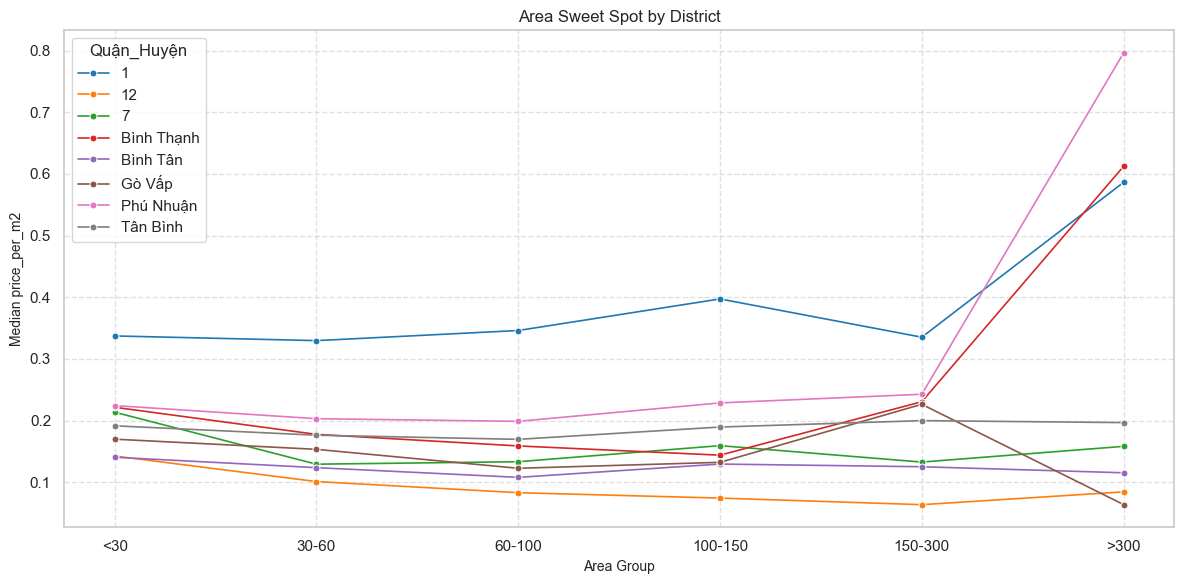

In [22]:
bins = [0, 30, 60, 100, 150, 300, float('inf')]
labels = ['<30', '30-60', '60-100', '100-150', '150-300', '>300']

df['Area Group'] = pd.cut(df['Diện tích'], bins=bins, labels=labels, right=False)

danh_sach_quan = ['1', '12', '7', 'Bình Thạnh', 'Bình Tân', 'Gò Vấp', 'Phú Nhuận', 'Tân Bình']

df['Quận'] = df['Quận'].astype(str)
df_plot = df[df['Quận'].isin(danh_sach_quan)].copy()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_plot,
    x='Area Group',
    y='Giá_trên_m2',
    hue='Quận',
    hue_order=danh_sach_quan,
    estimator=np.median,  
    errorbar=None,      
    marker='o',         
    markersize=5,
    linewidth=1.2,
    palette='tab10'          
)

plt.title('Area Sweet Spot by District', fontsize=12)
plt.xlabel('Area Group', fontsize=10)
plt.ylabel('Median price_per_m2', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='Quận_Huyện', loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

- Q1 dẫn đầu xuyên suốt mọi phân khúc diện tích → vị trí trung tâm tạo premium bền vững, không bị pha loãng bởi diện tích
- Phú Nhuận & Bình Thạnh bùng nổ ở >300m² (~0.8 & 0.61) → BĐS lớn tại đây mang tính luxury/đặc thù, giá/m² phi tuyến tính
- Q12, Bình Tân flat và thấp xuyên suốt → thị trường đại trà, thiếu premium driver
> Sweet spot thực tế: 60–150m² là vùng giá/m² ổn định nhất cho hầu hết quận → phù hợp để đầu tư thanh khoản tốt, ít biến động

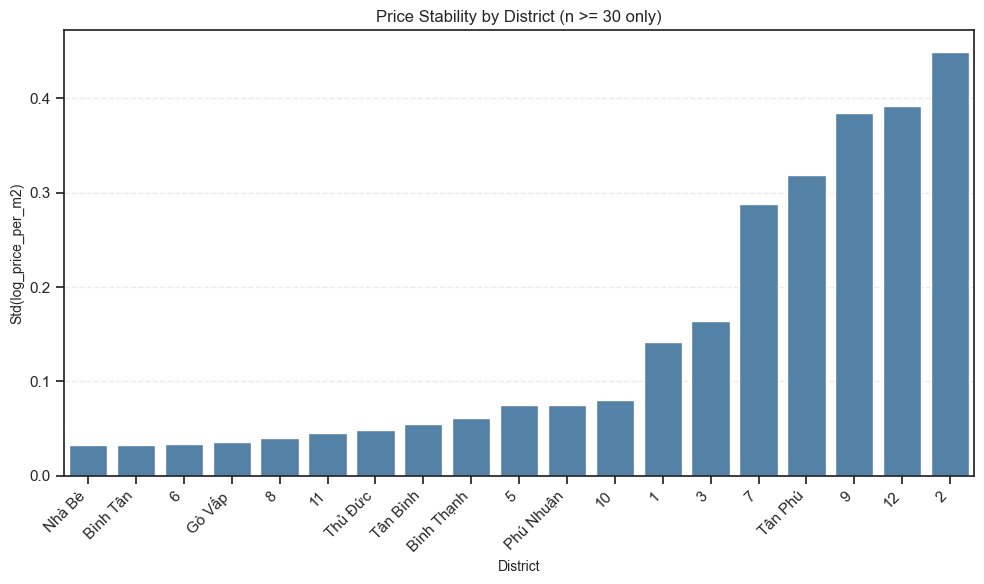

In [23]:
so_luong = df['Quận'].value_counts()
quan_dat_chuan = so_luong[so_luong >= 30].index

df_clean = df[df['Quận'].isin(quan_dat_chuan)].copy()

df_clean['log_price_per_m2'] = np.log1p(df_clean['Giá_trên_m2'])

stability_df = df_clean.groupby('Quận')['log_price_per_m2'].std().reset_index()
stability_df.rename(columns={'log_price_per_m2': 'Std(log_price_per_m2)'}, inplace=True)
stability_df = stability_df.sort_values(by='Std(log_price_per_m2)', ascending=True).dropna()

sns.set_style("ticks")
plt.figure(figsize=(10, 6))

sns.barplot(data=stability_df, x='Quận', y='Std(log_price_per_m2)', color='steelblue')

plt.title('Price Stability by District (n >= 30 only)', fontsize=12)
plt.xlabel('District', fontsize=10)
plt.ylabel('Std(log_price_per_m2)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

- Quận 2, 12, 9 biến động giá cao nhất (~0.38–0.44) → thị trường phân hóa mạnh, khó định giá chuẩn, rủi ro cao cho nhà đầu tư
- Nhà Bè, Q6, Bình Tân ổn định nhất (~0.03) → giá đồng đều, thanh khoản dễ dự đoán hơn
- Std dùng log-scale → chênh lệch thực tế giữa Q2 và Nhà Bè còn lớn hơn nhiều so với nhìn bằng mắt

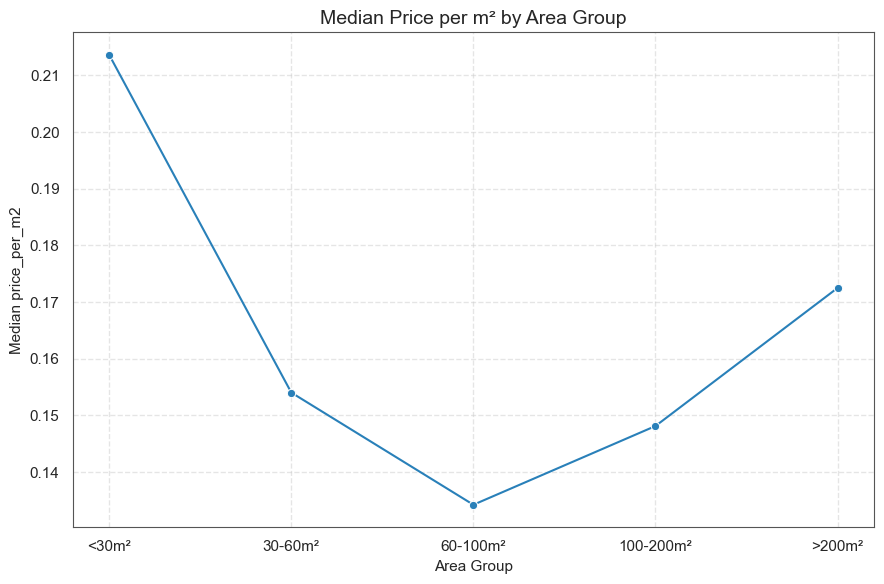

In [24]:
bins = [0, 30, 60, 100, 200, float('inf')]
labels = ['<30m²', '30-60m²', '60-100m²', '100-200m²', '>200m²']

df['Area Group'] = pd.cut(df['Diện tích'], bins=bins, labels=labels, right=False)

sns.set_style("white") 
plt.figure(figsize=(9, 6))

sns.lineplot(
    data=df, 
    x='Area Group', 
    y='Giá_trên_m2', 
    estimator=np.median, 
    errorbar=None, 
    marker='o',        
    markersize=6,
    linewidth=1.5,
    color='#2980b9'   
)

plt.title('Median Price per m² by Area Group', fontsize=14)
plt.xlabel('Area Group', fontsize=11)
plt.ylabel('Median price_per_m2', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

for spine in plt.gca().spines.values():
    spine.set_color('#555555')
    spine.set_linewidth(0.8)
    spine.set_visible(True)

plt.tight_layout()
plt.show()

- Căn nhỏ <30m² có giá/m² cao nhất (~0.214) → điển hình của hiệu ứng "premium nhỏ": người mua chấp nhận trả giá cao hơn/m² vì tổng giá trị tuyệt đối thấp, phù hợp túi tiền
- Đáy giá rơi vào 60–100m² (~0.133) → phân khúc này cạnh tranh nhất, nguồn cung dồi dào, ít premium → giá/m² bị nén xuống thấp nhất
- 200m² giá/m² tăng trở lại (~0.172) → hiệu ứng "luxury premium": BĐS diện tích lớn thường ở vị trí tốt, thiết kế cao cấp → giá/m² nhỉnh hơn nhóm trung

## Statistic EDA

### Ma trận tương quan - Đa cộng tuyến - Kiểm định giả thuyết

--- STATISTIC EDA: MA TRẬN TƯƠNG QUAN (CORRELATION HEATMAP) ---


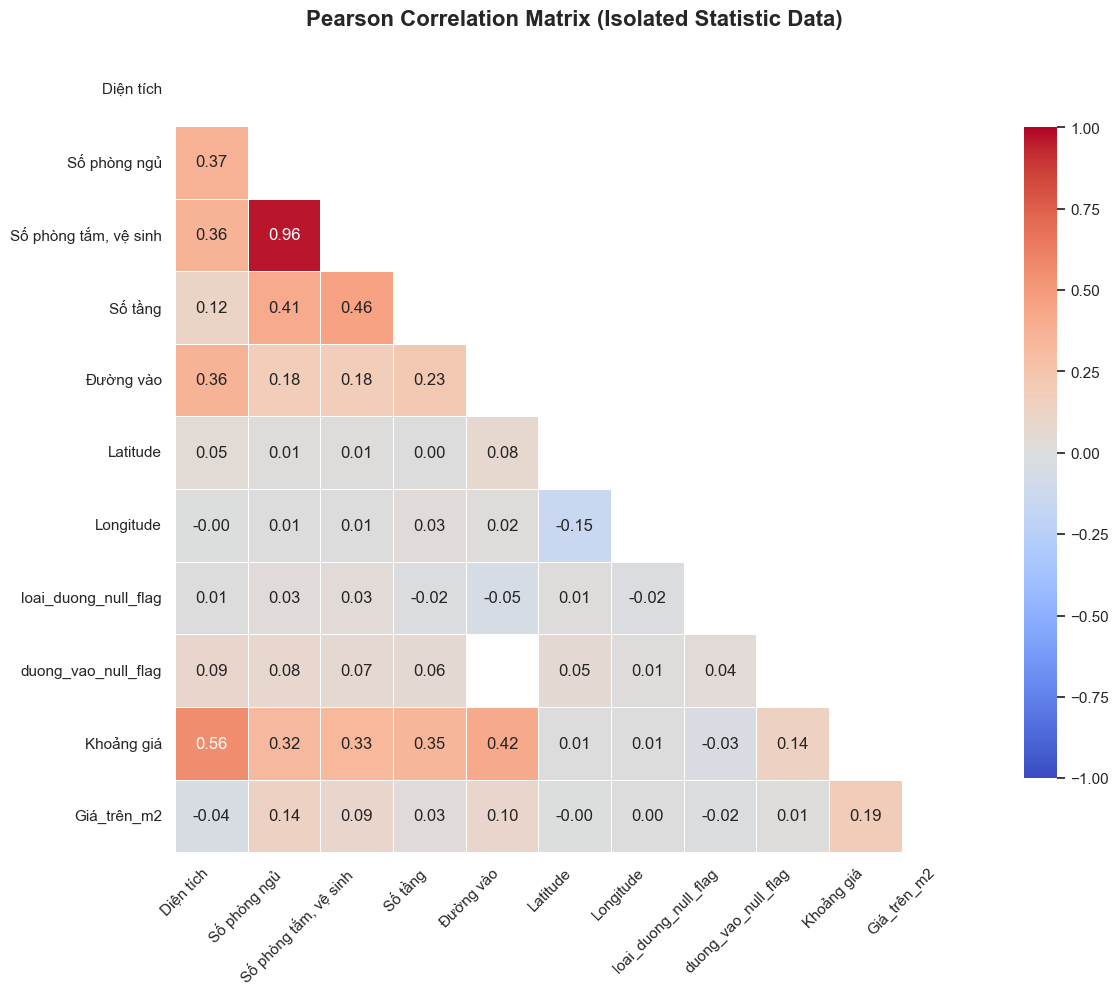

In [25]:
print("--- STATISTIC EDA: MA TRẬN TƯƠNG QUAN (CORRELATION HEATMAP) ---")

df_statistic = df.copy()

if df_statistic['Khoảng giá'].isnull().sum() > 0:
    df_statistic = df_statistic.dropna(subset=['Khoảng giá'])

df_numeric = df_statistic.select_dtypes(include=[np.number])

corr_matrix = df_numeric.corr()
plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title('Pearson Correlation Matrix (Isolated Statistic Data)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

print("--- STATISTIC EDA: KIỂM TRA ĐA CỘNG TUYẾN (VIF) ---")

numeric_features = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng']

X_vif = df_statistic[numeric_features].dropna()

X_vif_with_const = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_with_const.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_vif_with_const.values, i) 
                         for i in range(X_vif_with_const.shape[1])]

# Bỏ dòng const ra khỏi bảng kết quả và in ra
vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF_Score", ascending=False)
print(vif_data.to_string(index=False))

print("\n💡 Hướng dẫn đọc:")
print("- Nếu VIF < 5: Tuyệt vời, các biến hoàn toàn độc lập.")
print("- Nếu VIF từ 5 - 10: Có sự trùng lặp nhẹ, cần lưu ý.")
print("- Nếu VIF > 10: Đa cộng tuyến nặng! Bạn nên cân nhắc 'hi sinh' biến có VIF cao nhất.")

--- STATISTIC EDA: KIỂM TRA ĐA CỘNG TUYẾN (VIF) ---
              Feature  VIF_Score
Số phòng tắm, vệ sinh  14.883345
         Số phòng ngủ  14.236351
              Số tầng   1.288780
            Diện tích   1.159762

💡 Hướng dẫn đọc:
- Nếu VIF < 5: Tuyệt vời, các biến hoàn toàn độc lập.
- Nếu VIF từ 5 - 10: Có sự trùng lặp nhẹ, cần lưu ý.
- Nếu VIF > 10: Đa cộng tuyến nặng! Bạn nên cân nhắc 'hi sinh' biến có VIF cao nhất.


In [27]:
import scipy.stats as stats

print("--- STATISTIC EDA: KIỂM ĐỊNH GIẢ THUYẾT (ANOVA) ---")

def run_anova(df, category_col, target_col):
    """Hàm chạy ANOVA một chiều (One-way ANOVA)"""
    df_clean = df.dropna(subset=[category_col, target_col])
    
    groups = df_clean.groupby(category_col)[target_col].apply(list)

    groups = [g for g in groups if len(g) > 1]
    
    if len(groups) < 2:
        return f"Không đủ dữ liệu nhóm để chạy ANOVA cho '{category_col}'."
    
    f_stat, p_value = stats.f_oneway(*groups)
    
    print(f"\nKiểm định ANOVA giữa '{category_col}' và '{target_col}':")
    print(f"- F-Statistic: {f_stat:.2f}")
    print(f"- P-value: {p_value:.10f}") 
    
    if p_value < 0.05:
        print("-> KẾT LUẬN: Đủ bằng chứng thống kê (p < 0.05). Sự khác biệt về giá giữa các nhóm là CÓ Ý NGHĨA (Significant). Biến này quan trọng!")
    else:
        print("-> KẾT LUẬN: Không đủ bằng chứng (p >= 0.05). Sự khác biệt có thể chỉ do ngẫu nhiên. Biến này kém quan trọng.")

run_anova(df_statistic, category_col='Quận', target_col='Giá_trên_m2')

run_anova(df_statistic, category_col='Pháp lý', target_col='Giá_trên_m2')

--- STATISTIC EDA: KIỂM ĐỊNH GIẢ THUYẾT (ANOVA) ---

Kiểm định ANOVA giữa 'Quận' và 'Giá_trên_m2':
- F-Statistic: 0.75
- P-value: 0.7939374847
-> KẾT LUẬN: Không đủ bằng chứng (p >= 0.05). Sự khác biệt có thể chỉ do ngẫu nhiên. Biến này kém quan trọng.

Kiểm định ANOVA giữa 'Pháp lý' và 'Giá_trên_m2':
- F-Statistic: 0.12
- P-value: 0.8833632594
-> KẾT LUẬN: Không đủ bằng chứng (p >= 0.05). Sự khác biệt có thể chỉ do ngẫu nhiên. Biến này kém quan trọng.


### 1. Phân tích thống kê Giá

--- CHUYÊN ĐỀ 1: PHÂN TÍCH THỐNG KÊ BIẾN MỤC TIÊU ---


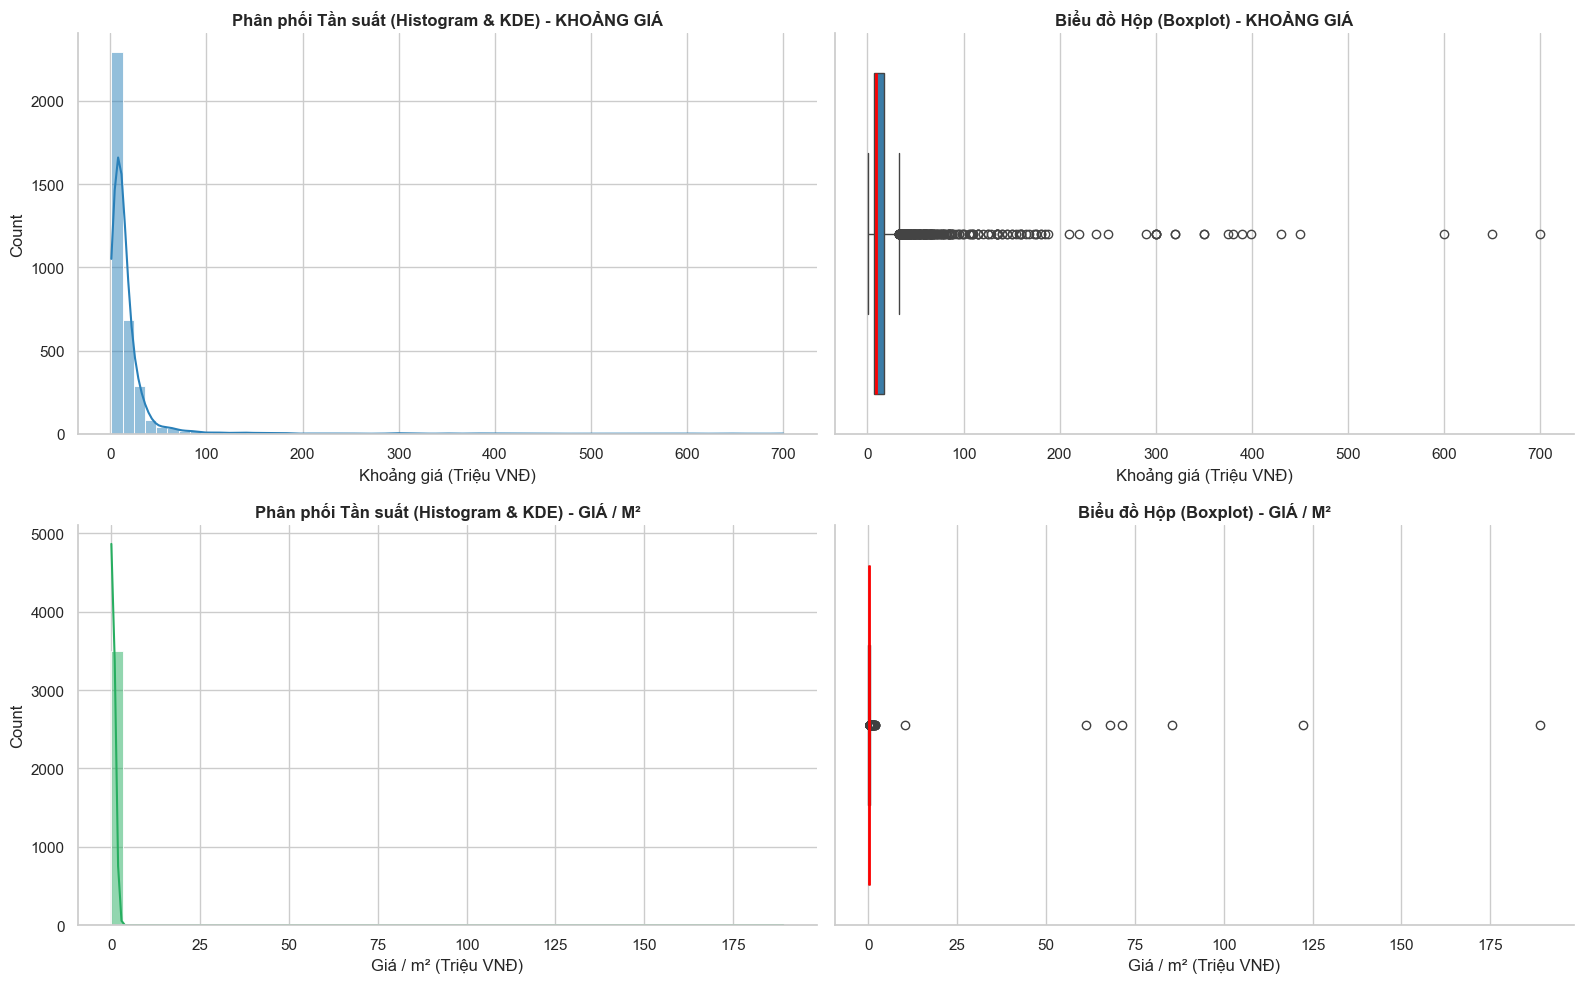


📊 BÁO CÁO THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS):
-----------------------------------------------------------------
🔹 Biến: KHOẢNG GIÁ
   - Độ lệch (Skewness): 9.79
   - Độ nhọn (Kurtosis): 131.30
   -> Chẩn đoán: Dữ liệu lệch phải RẤT NẶNG. Bắt buộc phải dùng biến đổi Log (Log Transformation) trước khi đưa vào mô hình Hồi quy tuyến tính.
   -> Cảnh báo: Kurtosis cao. Phần đuôi biểu đồ rất dày, chứng tỏ có lượng lớn điểm ngoại lai (Outliers) đắt bất thường. Boxplot cũng sẽ hiển thị rất nhiều chấm đen bên phải.
-----------------------------------------------------------------
🔹 Biến: GIÁ_TRÊN_M2
   - Độ lệch (Skewness): 31.28
   - Độ nhọn (Kurtosis): 1105.57
   -> Chẩn đoán: Dữ liệu lệch phải RẤT NẶNG. Bắt buộc phải dùng biến đổi Log (Log Transformation) trước khi đưa vào mô hình Hồi quy tuyến tính.
   -> Cảnh báo: Kurtosis cao. Phần đuôi biểu đồ rất dày, chứng tỏ có lượng lớn điểm ngoại lai (Outliers) đắt bất thường. Boxplot cũng sẽ hiển thị rất nhiều chấm đen bên phải.
-------------

In [28]:
print("--- CHUYÊN ĐỀ 1: PHÂN TÍCH THỐNG KÊ BIẾN MỤC TIÊU ---")

df_target = df_statistic.dropna(subset=['Khoảng giá', 'Giá_trên_m2']).copy()

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df_target['Khoảng giá'], kde=True, bins=60, color='#2980b9', ax=axes[0,0])
axes[0,0].set_title('Phân phối Tần suất (Histogram & KDE) - KHOẢNG GIÁ', fontweight='bold')
axes[0,0].set_xlabel('Khoảng giá (Triệu VNĐ)')

sns.boxplot(x=df_target['Khoảng giá'], color='#2980b9', ax=axes[0,1], medianprops={"color": "red", "linewidth": 2})
axes[0,1].set_title('Biểu đồ Hộp (Boxplot) - KHOẢNG GIÁ', fontweight='bold')
axes[0,1].set_xlabel('Khoảng giá (Triệu VNĐ)')

sns.histplot(df_target['Giá_trên_m2'], kde=True, bins=60, color='#27ae60', ax=axes[1,0])
axes[1,0].set_title('Phân phối Tần suất (Histogram & KDE) - GIÁ / M²', fontweight='bold')
axes[1,0].set_xlabel('Giá / m² (Triệu VNĐ)')

# 2.2 Boxplot
sns.boxplot(x=df_target['Giá_trên_m2'], color='#27ae60', ax=axes[1,1], medianprops={"color": "red", "linewidth": 2})
axes[1,1].set_title('Biểu đồ Hộp (Boxplot) - GIÁ / M²', fontweight='bold')
axes[1,1].set_xlabel('Giá / m² (Triệu VNĐ)')

plt.tight_layout()
plt.show()

print("\n📊 BÁO CÁO THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS):")
print("-" * 65)

for col in ['Khoảng giá', 'Giá_trên_m2']:
    skew_val = df_target[col].skew()
    kurt_val = df_target[col].kurtosis()
    
    print(f"🔹 Biến: {col.upper()}")
    print(f"   - Độ lệch (Skewness): {skew_val:.2f}")
    print(f"   - Độ nhọn (Kurtosis): {kurt_val:.2f}")
    
    if skew_val > 1:
        print("   -> Chẩn đoán: Dữ liệu lệch phải RẤT NẶNG. Bắt buộc phải dùng biến đổi Log (Log Transformation) trước khi đưa vào mô hình Hồi quy tuyến tính.")
    elif skew_val > 0.5:
        print("   -> Chẩn đoán: Dữ liệu lệch phải VỪA. Có thể cân nhắc dùng Log Transformation.")
    elif skew_val < -1:
        print("   -> Chẩn đoán: Dữ liệu lệch trái NẶNG.")
    else:
        print("   -> Chẩn đoán: Dữ liệu có phân phối khá chuẩn (Đối xứng).")
        
    if kurt_val > 3:
        print("   -> Cảnh báo: Kurtosis cao. Phần đuôi biểu đồ rất dày, chứng tỏ có lượng lớn điểm ngoại lai (Outliers) đắt bất thường. Boxplot cũng sẽ hiển thị rất nhiều chấm đen bên phải.")
    print("-" * 65)

### 2. PHÂN TÍCH ĐỊA LÝ

--- CHUYÊN ĐỀ 2: PHÂN TÍCH ĐỊA LÝ ---


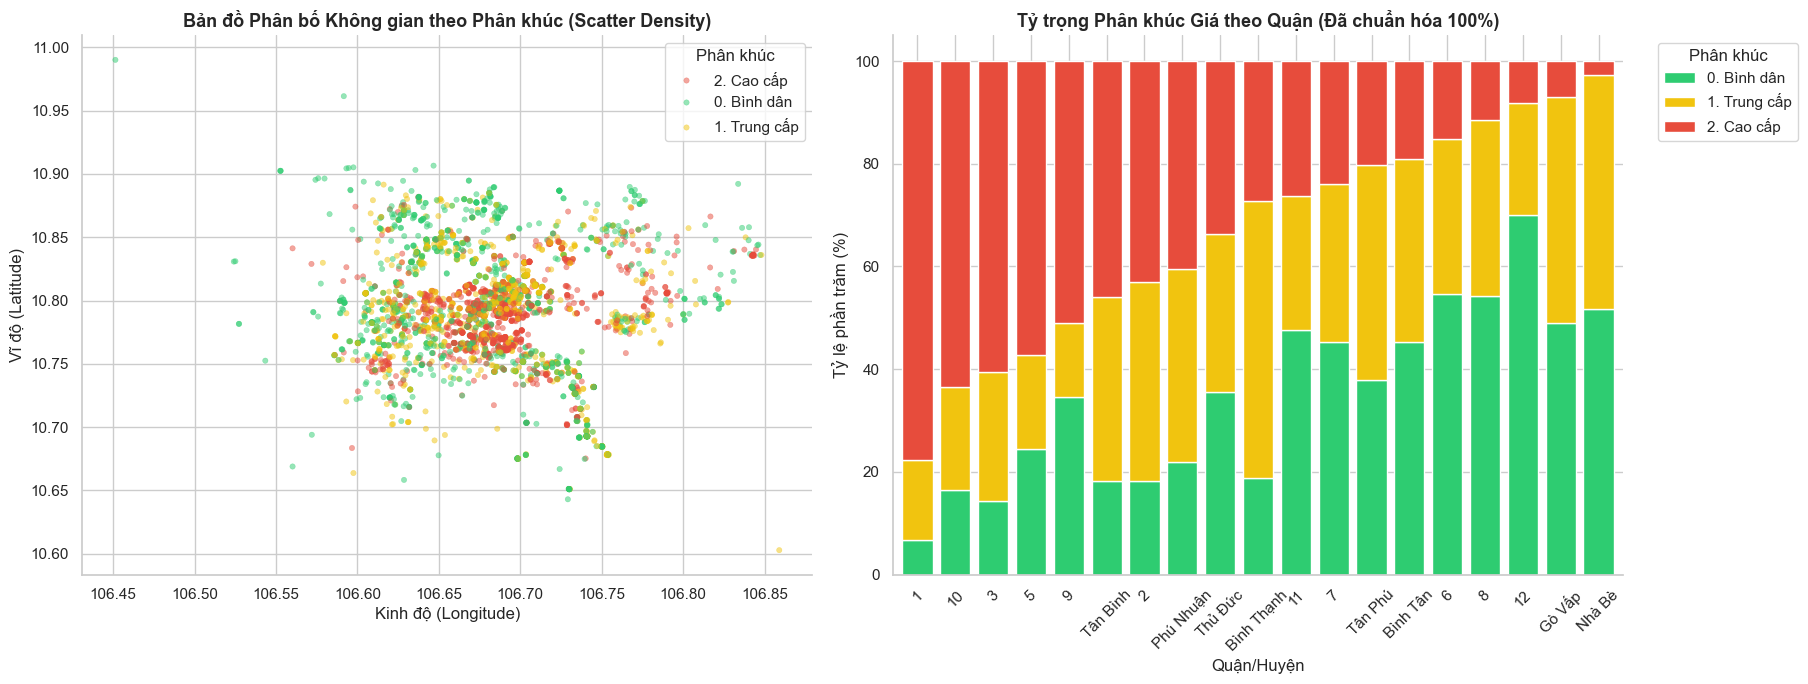


🛣️ TOP 5 TUYẾN ĐƯỜNG CÓ MẬT ĐỘ GIAO DỊCH CAO NHẤT:
- Huỳnh Tấn Phát: 151 tin đăng
- Quang Trung: 38 tin đăng
- Nơ Trang Long: 37 tin đăng
- Lê Văn Sỹ: 33 tin đăng
- Bùi Đình Túy: 33 tin đăng


In [29]:
print("--- CHUYÊN ĐỀ 2: PHÂN TÍCH ĐỊA LÝ ---")

df_geo = df_statistic.dropna(subset=['Khoảng giá', 'Latitude', 'Longitude', 'Quận']).copy()

lat_min, lat_max = 10.3, 11.2
lon_min, lon_max = 106.3, 106.9

df_geo = df_geo[
    (df_geo['Latitude'] >= lat_min) & (df_geo['Latitude'] <= lat_max) &
    (df_geo['Longitude'] >= lon_min) & (df_geo['Longitude'] <= lon_max)
]

q33 = df_geo['Khoảng giá'].quantile(0.33)
q67 = df_geo['Khoảng giá'].quantile(0.67)

def assign_label(price):
    if price <= q33: return '0. Bình dân'
    elif price <= q67: return '1. Trung cấp'
    else: return '2. Cao cấp'

df_geo['Phan_khuc_gia'] = df_geo['Khoảng giá'].apply(assign_label)

quan_counts = df_geo['Quận'].value_counts()
valid_quan = quan_counts[quan_counts >= 30].index
df_geo_filtered = df_geo[df_geo['Quận'].isin(valid_quan)]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=df_geo, x='Longitude', y='Latitude', 
    hue='Phan_khuc_gia', palette={'0. Bình dân': '#2ecc71', '1. Trung cấp': '#f1c40f', '2. Cao cấp': '#e74c3c'},
    s=15, alpha=0.5, edgecolor=None, ax=axes[0]
)

axes[0].set_title('Bản đồ Phân bố Không gian theo Phân khúc (Scatter Density)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Kinh độ (Longitude)')
axes[0].set_ylabel('Vĩ độ (Latitude)')
axes[0].legend(title='Phân khúc')

crosstab_pct = pd.crosstab(df_geo_filtered['Quận'], df_geo_filtered['Phan_khuc_gia'], normalize='index') * 100
crosstab_pct = crosstab_pct.sort_values(by='2. Cao cấp', ascending=False)

crosstab_pct.plot(
    kind='bar', stacked=True, 
    color=['#2ecc71', '#f1c40f', '#e74c3c'], 
    ax=axes[1], edgecolor='white', width=0.8
)

axes[1].set_title('Tỷ trọng Phân khúc Giá theo Quận (Đã chuẩn hóa 100%)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Quận/Huyện')
axes[1].set_ylabel('Tỷ lệ phần trăm (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Phân khúc', loc='upper right', bbox_to_anchor=(1.25, 1))

sns.despine(ax=axes[0])
sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

print("\n🛣️ TOP 5 TUYẾN ĐƯỜNG CÓ MẬT ĐỘ GIAO DỊCH CAO NHẤT:")
top_streets = df_geo['Đường'].value_counts().head(5)
for street, count in top_streets.items():
    print(f"- {street}: {count} tin đăng")

### 3. PHÂN TÍCH TƯƠNG QUAN CẤU TRÚC VẬT LÝ

--- CHUYÊN ĐỀ 3: PHÂN TÍCH TƯƠNG QUAN CẤU TRÚC VẬT LÝ ---


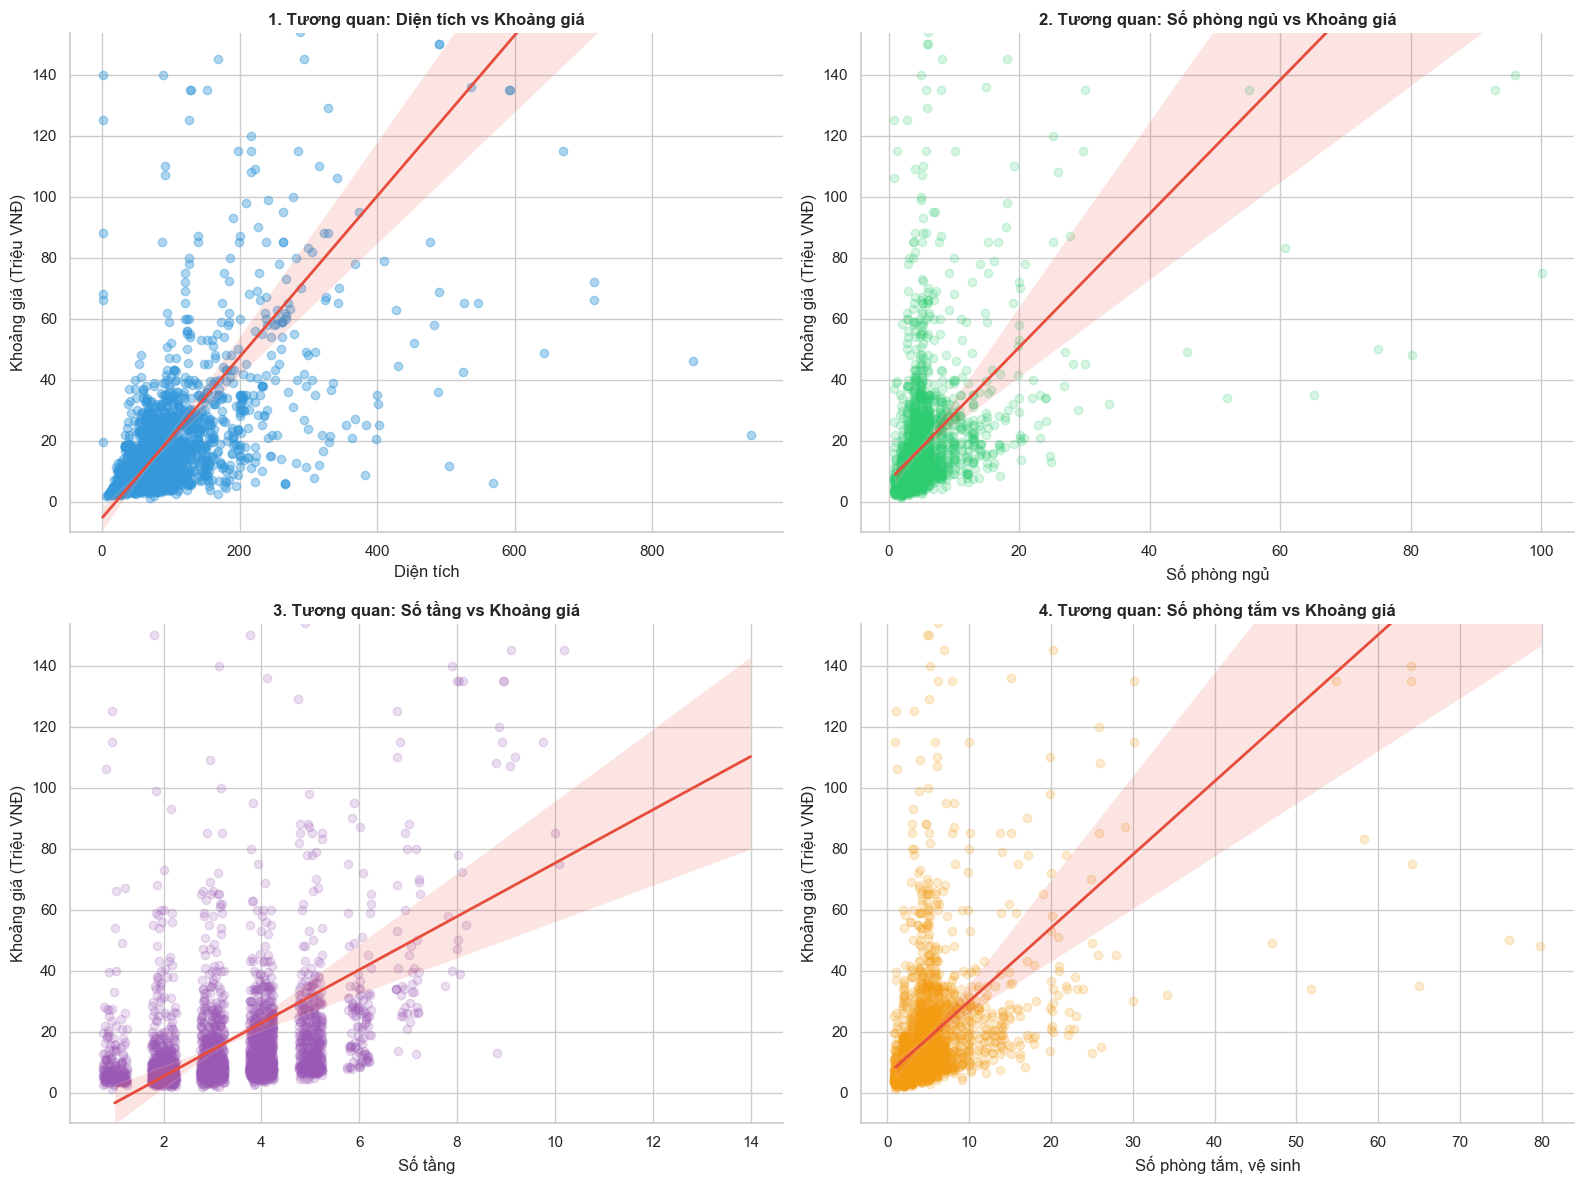

In [30]:
print("--- CHUYÊN ĐỀ 3: PHÂN TÍCH TƯƠNG QUAN CẤU TRÚC VẬT LÝ ---")

cols_vat_ly = ['Diện tích', 'Số phòng ngủ', 'Số tầng', 'Số phòng tắm, vệ sinh']
df_phys = df_statistic.dropna(subset=cols_vat_ly + ['Khoảng giá']).copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

scatter_style = {'alpha': 0.3, 's': 30, 'edgecolor': 'none'}
line_style = {'color': '#e74c3c', 'linewidth': 2}

sns.regplot(
    data=df_phys, x='Diện tích', y='Khoảng giá', 
    scatter_kws={'alpha': 0.4, 'color': '#3498db'}, line_kws=line_style, ax=axes[0,0]
)
axes[0,0].set_title('1. Tương quan: Diện tích vs Khoảng giá', fontweight='bold', fontsize=12)

sns.regplot(
    data=df_phys, x='Số phòng ngủ', y='Khoảng giá', x_jitter=0.25,
    scatter_kws={'alpha': 0.2, 'color': '#2ecc71'}, line_kws=line_style, ax=axes[0,1]
)
axes[0,1].set_title('2. Tương quan: Số phòng ngủ vs Khoảng giá', fontweight='bold', fontsize=12)

sns.regplot(
    data=df_phys, x='Số tầng', y='Khoảng giá', x_jitter=0.25,
    scatter_kws={'alpha': 0.2, 'color': '#9b59b6'}, line_kws=line_style, ax=axes[1,0]
)
axes[1,0].set_title('3. Tương quan: Số tầng vs Khoảng giá', fontweight='bold', fontsize=12)

sns.regplot(
    data=df_phys, x='Số phòng tắm, vệ sinh', y='Khoảng giá', x_jitter=0.25,
    scatter_kws={'alpha': 0.2, 'color': '#f39c12'}, line_kws=line_style, ax=axes[1,1]
)
axes[1,1].set_title('4. Tương quan: Số phòng tắm vs Khoảng giá', fontweight='bold', fontsize=12)

for i in range(2):
    for j in range(2):
        axes[i,j].set_ylabel('Khoảng giá (Triệu VNĐ)')
        axes[i,j].set_ylim(-10, df_phys['Khoảng giá'].quantile(0.99)) 

plt.tight_layout()
plt.show()

### 4. PHÂN TÍCH PHÁP LÝ & GIÁ TRỊ GIA TĂNG

--- CHUYÊN ĐỀ 4: PHÂN TÍCH PHÁP LÝ & GIÁ TRỊ GIA TĂNG ---


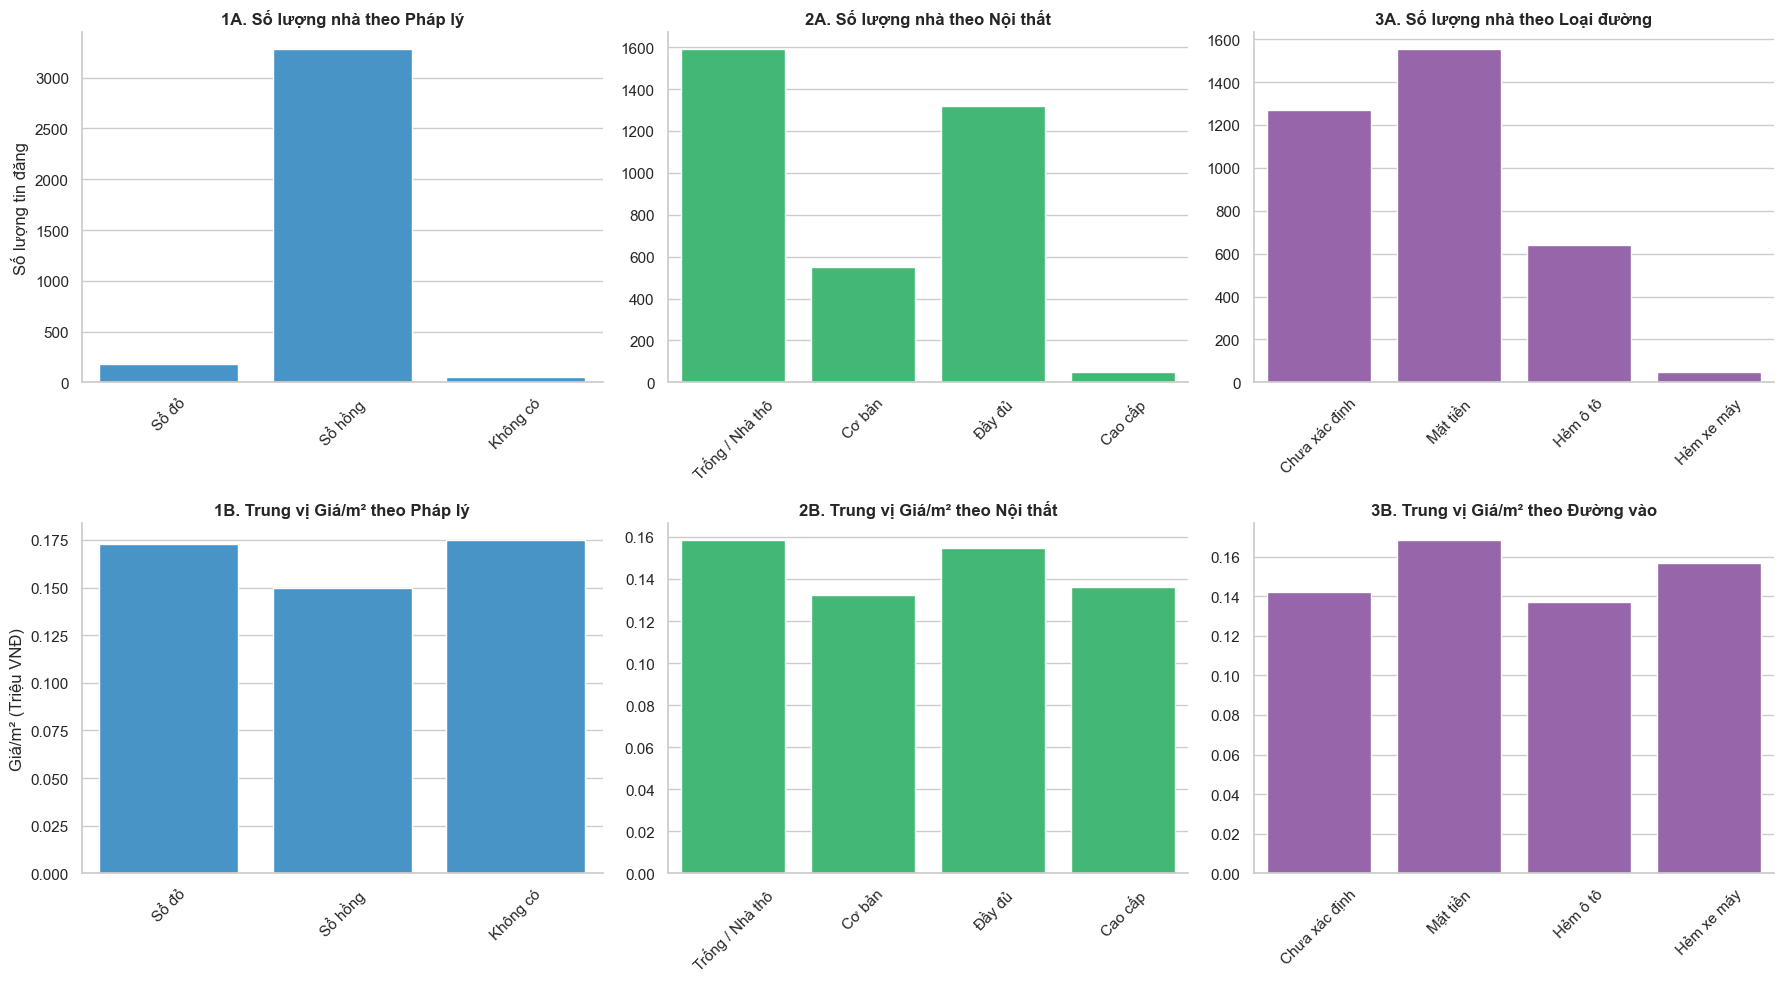

In [31]:
print("--- CHUYÊN ĐỀ 4: PHÂN TÍCH PHÁP LÝ & GIÁ TRỊ GIA TĂNG ---")

cols_cat = ['Pháp lý', 'Nội thất', 'Loại đường vào']
df_cat = df_statistic.dropna(subset=cols_cat + ['Giá_trên_m2']).copy()

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

color_phaply = '#3498db'
color_noithat = '#2ecc71'
color_duongvao = '#9b59b6'

sns.countplot(data=df_cat, x='Pháp lý', ax=axes[0,0], color=color_phaply)
axes[0,0].set_title('1A. Số lượng nhà theo Pháp lý', fontweight='bold')
axes[0,0].set_ylabel('Số lượng tin đăng')

sns.countplot(data=df_cat, x='Nội thất', ax=axes[0,1], color=color_noithat)
axes[0,1].set_title('2A. Số lượng nhà theo Nội thất', fontweight='bold')
axes[0,1].set_ylabel('')

sns.countplot(data=df_cat, x='Loại đường vào', ax=axes[0,2], color=color_duongvao)
axes[0,2].set_title('3A. Số lượng nhà theo Loại đường', fontweight='bold')
axes[0,2].set_ylabel('')

sns.barplot(data=df_cat, x='Pháp lý', y='Giá_trên_m2', estimator=np.median, errorbar=None, ax=axes[1,0], color=color_phaply)
axes[1,0].set_title('1B. Trung vị Giá/m² theo Pháp lý', fontweight='bold')
axes[1,0].set_ylabel('Giá/m² (Triệu VNĐ)')

sns.barplot(data=df_cat, x='Nội thất', y='Giá_trên_m2', estimator=np.median, errorbar=None, ax=axes[1,1], color=color_noithat)
axes[1,1].set_title('2B. Trung vị Giá/m² theo Nội thất', fontweight='bold')
axes[1,1].set_ylabel('')

sns.barplot(data=df_cat, x='Loại đường vào', y='Giá_trên_m2', estimator=np.median, errorbar=None, ax=axes[1,2], color=color_duongvao)
axes[1,2].set_title('3B. Trung vị Giá/m² theo Đường vào', fontweight='bold')
axes[1,2].set_ylabel('')

for i in range(2):
    for j in range(3):
        axes[i,j].tick_params(axis='x', rotation=45)
        axes[i,j].set_xlabel('')

plt.tight_layout()
plt.show()

### 5. HEATMAP GIÁ TRUNG BÌNH THEO QUẬN × LOẠI ĐƯỜNG VÀO
> **Mục tiêu:** Phát hiện tổ hợp (Quận, Loại đường vào) tạo premium giá rõ rệt → cơ sở cho interaction feature ở bước FE.

--- CHUYÊN ĐỀ 5: HEATMAP GIÁ TRUNG BÌNH THEO QUẬN × LOẠI ĐƯỜNG VÀO ---


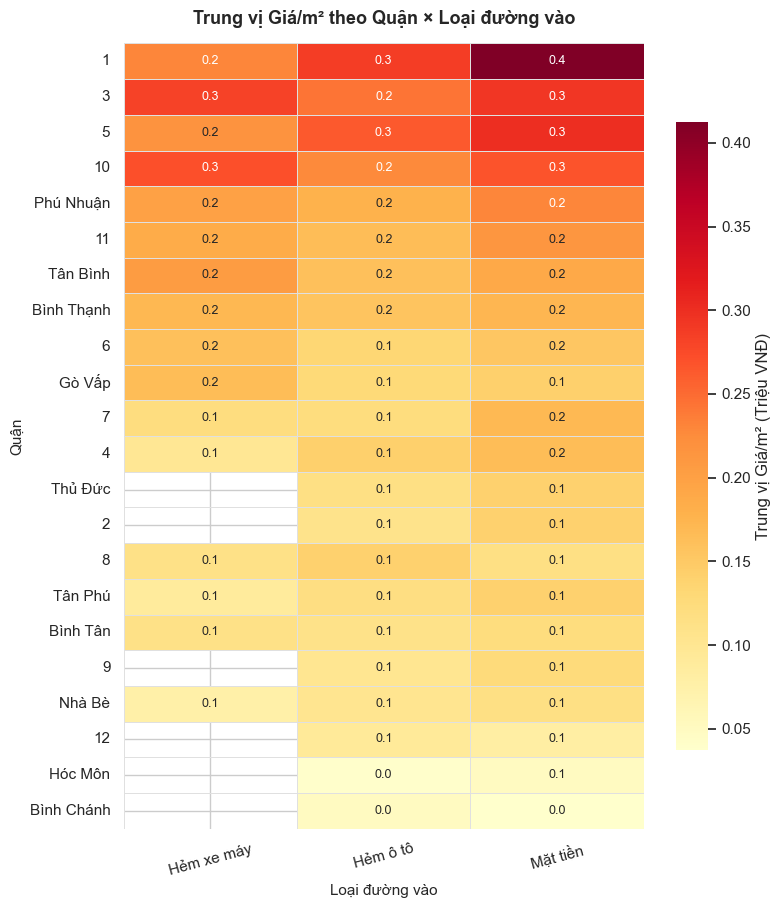


🔥 Top 5 tổ hợp Quận × Đường vào có giá/m² cao nhất:
                     median  count
Quận Loại đường vào               
1    Mặt tiền          0.41    149
     Chưa xác định     0.34     78
5    Mặt tiền          0.30     24
3    Mặt tiền          0.29     68
1    Hẻm ô tô          0.29     53

💡 Insight: Cột "Mặt tiền" luôn tạo premium rõ rệt bất kể quận → Interaction feature Quận_x_LoaiDuong sẽ được tạo ở bước FE.


In [32]:
print('--- CHUYÊN ĐỀ 5: HEATMAP GIÁ TRUNG BÌNH THEO QUẬN × LOẠI ĐƯỜNG VÀO ---')

# ── 1. Chuẩn bị dữ liệu ──────────────────────────────────────────
_cols_heat = ['Quận', 'Loại đường vào', 'Giá_trên_m2']
df_heat = df_statistic.dropna(subset=_cols_heat).copy()

# Chỉ giữ quận có đủ mẫu (≥ 20) để tránh ô trắng / nhiễu thống kê
_quan_valid = df_heat['Quận'].value_counts()
_quan_valid = _quan_valid[_quan_valid >= 20].index
df_heat = df_heat[df_heat['Quận'].isin(_quan_valid)]

# Thứ tự cột theo mức độ tiếp cận tăng dần
_road_order = ['Hẻm xe máy', 'Hẻm ô tô', 'Mặt tiền']
_road_order = [r for r in _road_order if r in df_heat['Loại đường vào'].unique()]

# ── 2. Pivot table: median Giá/m² ────────────────────────────────
pivot = (
    df_heat
    .groupby(['Quận', 'Loại đường vào'])['Giá_trên_m2']
    .median()
    .unstack('Loại đường vào')
    .reindex(columns=_road_order)
)
# Sắp xếp quận theo median tổng thể (dễ đọc)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

# ── 3. Vẽ heatmap ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, max(6, len(pivot) * 0.42)))

sns.heatmap(
    pivot,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='#e0e0e0',
    cbar_kws={'label': 'Trung vị Giá/m² (Triệu VNĐ)', 'shrink': 0.8},
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title(
    'Trung vị Giá/m² theo Quận × Loại đường vào',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel('Loại đường vào', fontsize=11)
ax.set_ylabel('Quận', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# ── 4. Top 3 tổ hợp cao nhất ─────────────────────────────────────
_top_combo = (
    df_heat
    .groupby(['Quận', 'Loại đường vào'])['Giá_trên_m2']
    .agg(median='median', count='count')
    .query('count >= 5')
    .sort_values('median', ascending=False)
    .head(5)
)
print('\n🔥 Top 5 tổ hợp Quận × Đường vào có giá/m² cao nhất:')
print(_top_combo.round(2).to_string())
print('\n💡 Insight: Cột "Mặt tiền" luôn tạo premium rõ rệt bất kể quận',
      '→ Interaction feature Quận_x_LoaiDuong sẽ được tạo ở bước FE.')

### 6. OUTLIER ANALYSIS CÓ CHỦ ĐÍCH — NOISE vs SIGNAL
> **Phương pháp:** IQR fence trên `Giá_trên_m2` + `Diện tích`.  
> Phân loại **Signal** (outlier hợp lệ về mặt thị trường) vs **Noise** (lỗi dữ liệu / cần loại).
> Tiêu chí phân loại:
> - **Noise**: Giá/m² cực thấp (< Q1 − 3×IQR) **hoặc** Diện tích < 10 m² / > 700 m²
> - **Signal**: Outlier giá cao nhưng Quận trung tâm (1, 3, Phú Nhuận) + Mặt tiền → phù hợp thị trường

--- CHUYÊN ĐỀ 6: OUTLIER ANALYSIS — NOISE vs SIGNAL ---

📊 Phân loại outlier:
  Normal                                    3042 (86.6%)
  Signal – Outlier nhẹ (giữ lại)             378 (10.8%)
  Signal – Luxury trung tâm                   55 (1.6%)
  Signal – Premium quận trung tâm             18 (0.5%)
  Noise – Diện tích bất thường                17 (0.5%)
  Noise – Giá/m² bất thường                    2 (0.1%)


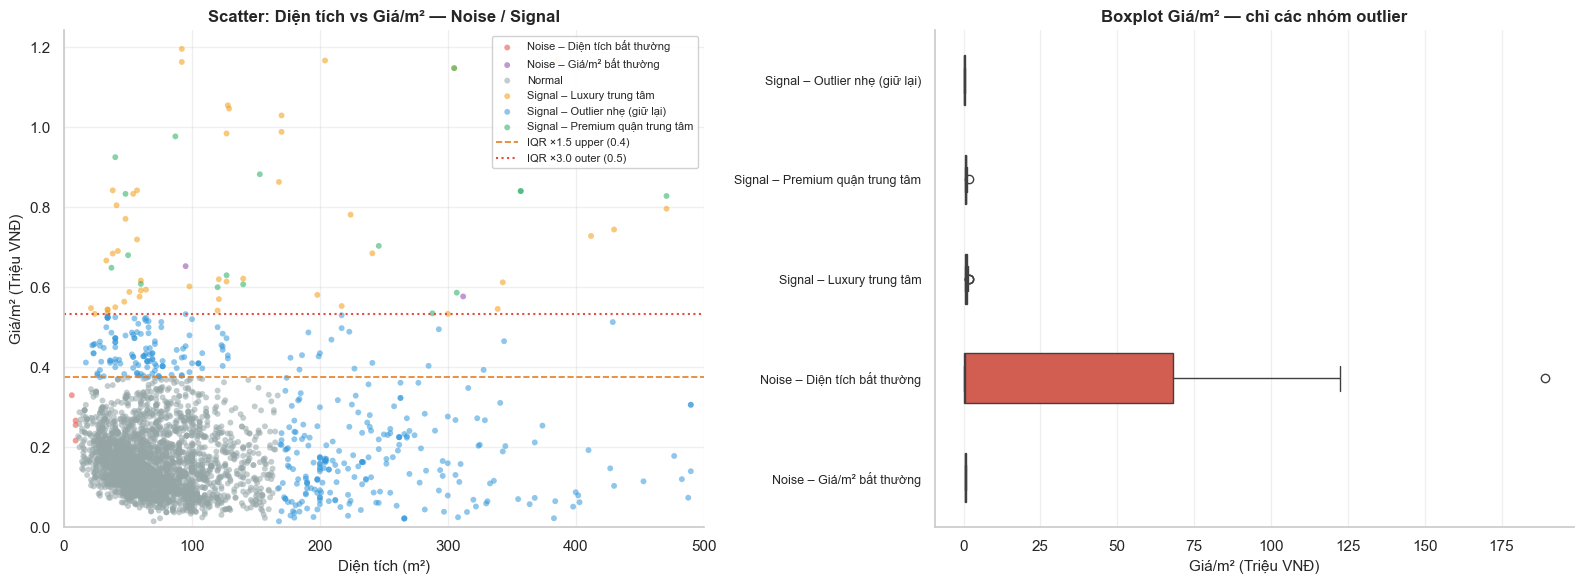


🔍 Tổng noise cần loại / cap: 19 / 3512 (0.5%)
📌 Khuyến nghị:
  - "Noise – Diện tích bất thường" → DROP tại bước FE (lỗi cào dữ liệu)
  - "Noise – Giá/m² cực thấp"      → DROP (giá không hợp lệ)
  - "Noise – Giá/m² bất thường"    → CAP tại upper outer fence hoặc DROP
  - Signal (Luxury / Premium)      → GIỮ LẠI, gắn flag is_luxury=1


In [33]:
print('--- CHUYÊN ĐỀ 6: OUTLIER ANALYSIS — NOISE vs SIGNAL ---')
warnings.filterwarnings('ignore')

# ── 1. Tính IQR fence cho Giá_trên_m2 và Diện tích ───────────────
df_out = df_statistic.dropna(subset=['Giá_trên_m2', 'Diện tích', 'Quận', 'Loại đường vào']).copy()

def iqr_bounds(series, k_inner=1.5, k_outer=3.0):
    """Trả về (lower_inner, upper_inner, lower_outer, upper_outer)"""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (Q1 - k_inner*IQR, Q3 + k_inner*IQR,
            Q1 - k_outer*IQR, Q3 + k_outer*IQR)

g_lo1, g_hi1, g_lo3, g_hi3 = iqr_bounds(df_out['Giá_trên_m2'])
d_lo1, d_hi1, d_lo3, d_hi3 = iqr_bounds(df_out['Diện tích'])

# ── 2. Phân loại từng quan sát ───────────────────────────────────
_CENTRAL_QUAN = {'1', '3', 'Phú Nhuận', 'Bình Thạnh', '4', '5', '10', '11'}

def classify_outlier(row):
    g, d = row['Giá_trên_m2'], row['Diện tích']
    quan  = str(row['Quận'])
    loai  = str(row['Loại đường vào'])

    # Noise cứng: diện tích bất thường hoặc giá âm / gần 0
    if d < 10 or d > 700:
        return 'Noise – Diện tích bất thường'
    if g <= 0 :
        return 'Noise – Giá/m² cực thấp'

    # Outlier giá cao
    if g > g_hi3:
        if quan in _CENTRAL_QUAN and loai == 'Mặt tiền':
            return 'Signal – Luxury trung tâm'
        elif quan in _CENTRAL_QUAN:
            return 'Signal – Premium quận trung tâm'
        else:
            return 'Noise – Giá/m² bất thường'

    # Inner fence outlier nhẹ
    if g > g_hi1 or d > d_hi1:
        return 'Signal – Outlier nhẹ (giữ lại)'

    return 'Normal'

df_out['outlier_label'] = df_out.apply(classify_outlier, axis=1)

# ── 3. Tóm tắt số lượng từng nhóm ────────────────────────────────
_summary = df_out['outlier_label'].value_counts()
print('\n📊 Phân loại outlier:')
for label, cnt in _summary.items():
    pct = cnt / len(df_out) * 100
    print(f'  {label:<40} {cnt:>5} ({pct:.1f}%)')

# ── 4. Scatter: Diện tích vs Giá_trên_m2, màu theo label ─────────
_palette = {
    'Normal':                       '#95a5a6',
    'Signal – Outlier nhẹ (giữ lại)':'#3498db',
    'Signal – Premium quận trung tâm':'#27ae60',
    'Signal – Luxury trung tâm':     '#f39c12',
    'Noise – Diện tích bất thường':  '#e74c3c',
    'Noise – Giá/m² cực thấp':       '#c0392b',
    'Noise – Giá/m² bất thường':     '#8e44ad',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Diện tích vs Giá/m²
for lbl, grp in df_out.groupby('outlier_label'):
    axes[0].scatter(
        grp['Diện tích'], grp['Giá_trên_m2'],
        c=_palette.get(lbl, '#cccccc'),
        label=lbl, alpha=0.55, s=18, edgecolors='none'
    )
axes[0].axhline(g_hi1, color='#e67e22', ls='--', lw=1.2, label=f'IQR ×1.5 upper ({g_hi1:.1f})')
axes[0].axhline(g_hi3, color='#e74c3c', ls=':',  lw=1.5, label=f'IQR ×3.0 outer ({g_hi3:.1f})')
axes[0].set_xlabel('Diện tích (m²)', fontsize=11)
axes[0].set_ylabel('Giá/m² (Triệu VNĐ)', fontsize=11)
axes[0].set_title('Scatter: Diện tích vs Giá/m² — Noise / Signal', fontweight='bold')
axes[0].set_xlim(0, 500)
axes[0].set_ylim(0, df_out['Giá_trên_m2'].quantile(0.995) * 1.1)
axes[0].legend(fontsize=8, loc='upper right', framealpha=0.9)
axes[0].grid(True, alpha=0.3)

# Plot 2: Boxplot Giá/m² theo label (không vẽ Normal để dễ đọc)
_df_notnormal = df_out[df_out['outlier_label'] != 'Normal']
if not _df_notnormal.empty:
    _order = [l for l in _palette if l in _df_notnormal['outlier_label'].unique() and l != 'Normal']
    sns.boxplot(
        data=_df_notnormal,
        y='outlier_label', x='Giá_trên_m2',
        order=_order,
        palette=_palette,
        ax=axes[1],
        width=0.5
    )
axes[1].set_title('Boxplot Giá/m² — chỉ các nhóm outlier', fontweight='bold')
axes[1].set_xlabel('Giá/m² (Triệu VNĐ)', fontsize=11)
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelsize=9)
axes[1].grid(True, axis='x', alpha=0.3)

sns.despine(ax=axes[0])
sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

# ── 5. Quyết định xử lý ──────────────────────────────────────────
_noise_mask = df_out['outlier_label'].str.startswith('Noise')
_noise_cnt  = _noise_mask.sum()
_total      = len(df_out)
print(f'\n🔍 Tổng noise cần loại / cap: {_noise_cnt} / {_total} ({_noise_cnt/_total*100:.1f}%)')
print('📌 Khuyến nghị:')
print('  - "Noise – Diện tích bất thường" → DROP tại bước FE (lỗi cào dữ liệu)')
print('  - "Noise – Giá/m² cực thấp"      → DROP (giá không hợp lệ)')
print('  - "Noise – Giá/m² bất thường"    → CAP tại upper outer fence hoặc DROP')
print('  - Signal (Luxury / Premium)      → GIỮ LẠI, gắn flag is_luxury=1')

### 7. TỔNG KẾT EDA — TOP 5 FEATURES & CẦU NỐI SANG FEATURE ENGINEERING
> Cell này tính **feature importance proxy** bằng Spearman correlation + mutual information,  
> sau đó in bảng hành động cụ thể cho từng feature tại bước FE.

In [34]:
print('--- TỔNG KẾT EDA & CẦU NỐI SANG FEATURE ENGINEERING ---')
from scipy.stats import spearmanr
try:
    from sklearn.feature_selection import mutual_info_regression
    _HAS_SKLEARN = True
except ImportError:
    _HAS_SKLEARN = False
    print('⚠️  sklearn chưa cài — bỏ qua MI score, chỉ dùng Spearman.')

# ── 1. Tính Spearman |ρ| với Giá_trên_m2 ────────────────────────
_feat_cols = ['Diện tích', 'Số phòng ngủ', 'Số tầng']
_cat_map   = {'Loại đường vào': {'Hẻm xe máy': 1, 'Hẻm ô tô': 2, 'Mặt tiền': 3},
               'Khoảng giá':    None}   # sử dụng trực tiếp

df_fe_prep = df_statistic.dropna(subset=['Giá_trên_m2'] + _feat_cols).copy()

# Encode Loại đường vào
if 'Loại đường vào' in df_fe_prep.columns:
    df_fe_prep['_loai_enc'] = df_fe_prep['Loại đường vào'].map(
        {'Hẻm xe máy': 1, 'Hẻm ô tô': 2, 'Mặt tiền': 3, 'Chưa xác định': 0}
    )
    _feat_cols_enc = _feat_cols + ['_loai_enc']
else:
    _feat_cols_enc = _feat_cols


df_fe_prep = df_fe_prep.dropna(subset=_feat_cols_enc)

_spearman_scores = {}
for col in _feat_cols_enc:
    rho, _ = spearmanr(df_fe_prep[col], df_fe_prep['Giá_trên_m2'])
    _spearman_scores[col] = abs(rho)

# ── 2. Mutual Information (nếu có sklearn) ────────────────────────
_mi_scores = {}
if _HAS_SKLEARN:
    _X = df_fe_prep[_feat_cols_enc].values
    _y = df_fe_prep['Giá_trên_m2'].values
    _mi = mutual_info_regression(_X, _y, random_state=42)
    _mi_scores = dict(zip(_feat_cols_enc, _mi / max(_mi)))  # normalize 0-1

# ── 3. Tổng hợp bảng xếp hạng ────────────────────────────────────
_display_names = {
    'Khoảng giá':  'Khoảng giá (log-target)',
    'Diện tích':   'Diện tích',
    '_loai_enc':   'Loại đường vào (ordinal)',
    'Số phòng ngủ':'Số phòng ngủ',
    'Số tầng':     'Số tầng',
}

_rows = []
for col in _feat_cols_enc:
    _rows.append({
        'Feature':       _display_names.get(col, col),
        'Spearman |ρ|':  round(_spearman_scores.get(col, 0), 3),
        'MI (norm)':     round(_mi_scores.get(col, float('nan')), 3) if _HAS_SKLEARN else 'N/A',
    })

df_rank = pd.DataFrame(_rows).sort_values('Spearman |ρ|', ascending=False).reset_index(drop=True)
df_rank.index += 1

print('\n📊 Xếp hạng feature theo tương quan với Giá_trên_m2:')
print(df_rank.to_string())

# ── 4. Bảng hành động FE ─────────────────────────────────────────
_fe_plan = [
    ('Khoảng giá',          'Log1p transform → log_gia', 'Giảm skewness 9.8 → ~0.3'),
    ('Diện tích',           'Log1p + outlier cap (10–500 m²)', 'Loại noise diện tích bất thường'),
    ('Loại đường vào',      'Ordinal encode (0-3) + flag is_mat_tien', 'Bắt signal premium mặt tiền'),
    ('Quận',                'Target encode (smoothed, m=10)', 'Tránh overfit quận ít mẫu'),
    ('Diện tích × LoaiDV',  'Interaction: dien_tich_x_loai_duong', 'Heatmap cho thấy tổ hợp phi tuyến'),
    ('Số phòng ngủ',        'Giữ nguyên + clip [1, 10]', 'VIF cao → cần monitor đa cộng tuyến'),
    ('Số tầng',             'Giữ nguyên + bin (1,2,3,4+)', 'Ít tương quan đơn lẻ, có ích khi bin'),
]

df_plan = pd.DataFrame(_fe_plan, columns=['Feature', 'Hành động FE', 'Lý do'])
df_plan.index += 1

print('\n' + '='*72)
print('🗺️  KẾ HOẠCH FEATURE ENGINEERING (từ EDA)')
print('='*72)
# in dạng bảng thủ công để đẹp trong notebook
_col_w = [22, 38, 42]
_header = f"{'Feature':<{_col_w[0]}} {'Hành động FE':<{_col_w[1]}} {'Lý do':<{_col_w[2]}}"
print(_header)
print('-' * sum(_col_w))
for _, row in df_plan.iterrows():
    print(f"{row['Feature']:<{_col_w[0]}} {row['Hành động FE']:<{_col_w[1]}} {row['Lý do']:<{_col_w[2]}}")
print('='*72)
print('\n✅ EDA hoàn tất. Tiếp theo: Section 3.3 Feature Engineering.')

--- TỔNG KẾT EDA & CẦU NỐI SANG FEATURE ENGINEERING ---

📊 Xếp hạng feature theo tương quan với Giá_trên_m2:
                    Feature  Spearman |ρ|  MI (norm)
1                   Số tầng         0.459      0.598
2              Số phòng ngủ         0.281      0.249
3  Loại đường vào (ordinal)         0.148      0.083
4                 Diện tích         0.125      1.000

🗺️  KẾ HOẠCH FEATURE ENGINEERING (từ EDA)
Feature                Hành động FE                           Lý do                                     
------------------------------------------------------------------------------------------------------
Khoảng giá             Log1p transform → log_gia              Giảm skewness 9.8 → ~0.3                  
Diện tích              Log1p + outlier cap (10–500 m²)        Loại noise diện tích bất thường           
Loại đường vào         Ordinal encode (0-3) + flag is_mat_tien Bắt signal premium mặt tiền               
Quận                   Target encode (smoothed, m=10)      

# 3.3 Feature Engineering



### 3.3.0. Tích hợp LLM sinh thuộc tính: 

- Mã nguồn gọi LLM được lưu trữ và thực thi tại tệp llm-qwen-extract-bds.ipynb trên nền tảng Kaggle do giới hạn về phần cứng
> Dữ liệu đầu vào: C:\Users\ADMIN\OneDrive\Desktop\Thu thập và tiền xử lí dữ liệu bất động sản phục vụ cho bài toán phân loại theo giá\data\Processed\Cleaned_data\Cleaned_data.csv

> Dữ liệu đầu ra: C:\Users\ADMIN\OneDrive\Desktop\Thu thập và tiền xử lí dữ liệu bất động sản phục vụ cho bài toán phân loại theo giá\data\Processed\Cleaned_data\Cleaned_data_qwen.csv

## 3.3.1. Load dữ liệu đầu vào

In [35]:
# 1. Đọc dữ liệu từ file CSV
file_path = CLEANED_LLM_DIR / "Cleaned_data_qwen.csv"
df = pd.read_csv(file_path)

target_col = 'Khoảng giá'
split_col = 'Loại_Dữ_Liệu'

if target_col not in df.columns or split_col not in df.columns:
    raise ValueError(f"Không tìm thấy cột '{target_col}' hoặc '{split_col}' trong tập dữ liệu!")

# Drop duplicate theo business key — khôi phục lại kết quả dedup của NB02
BIZ_KEY = ['Địa chỉ', 'Khoảng giá', 'Diện tích',
           'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Số tầng']
before = len(df)
df = df.drop_duplicates(subset=BIZ_KEY, keep='first').reset_index(drop=True)
print(f"🔄 Loại bỏ duplicate: {before} → {len(df)} hàng (dropped {before - len(df)})")

train_data = df[df[split_col].str.lower() == 'train']
test_data  = df[df[split_col].str.lower() == 'test']

X_train = train_data.drop(columns=[target_col, split_col])
y_train = train_data[target_col]

X_test = test_data.drop(columns=[target_col, split_col])
y_test = test_data[target_col]

print("✅ Đã tách dữ liệu thành công!")
print("-" * 30)
print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước y_train: {y_train.shape}")
print(f"Kích thước X_test:  {X_test.shape}")
print(f"Kích thước y_test:  {y_test.shape}")

🔄 Loại bỏ duplicate: 3628 → 3500 hàng (dropped 128)
✅ Đã tách dữ liệu thành công!
------------------------------
Kích thước X_train: (2823, 23)
Kích thước y_train: (2823,)
Kích thước X_test:  (677, 23)
Kích thước y_test:  (677,)


In [36]:
y_train.head()

0     5.8
1     8.5
2     9.4
3    14.5
4     4.8
Name: Khoảng giá, dtype: str

In [37]:
X_train.columns

Index(['Link', 'Địa chỉ', 'Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh',
       'Số tầng', 'Đường vào', 'Pháp lý', 'Nội thất', 'Latitude', 'Longitude',
       'Mô tả', 'Loại đường vào', 'Đường', 'Phường/Xã', 'Quận',
       'loai_duong_null_flag', 'duong_vao_null_flag', 'hem_xe_hoi',
       'gan_cho_sieu_thi', 'gan_truong_hoc', 'gan_benh_vien',
       'gan_cong_vien_ho_nuoc'],
      dtype='str')

### Hàm checkpoint

In [38]:
_SHAPE_SNAPSHOTS = {}

def checkpoint(tag, show_null=True):
    """In shape + null counts; lưu snapshot để so sánh sau."""
    global _SHAPE_SNAPSHOTS
    print(f"\n{'─'*55}")
    print(f"[CHECKPOINT] {tag}")
    print(f"  X_train : {X_train.shape}  | X_test : {X_test.shape}")
    print(f"  y_train : {y_train.shape}  | y_test : {y_test.shape}")

    if show_null:
        null_tr = X_train.isnull().sum()
        null_te = X_test.isnull().sum()
        cols_with_null = null_tr[null_tr > 0].index.union(null_te[null_te > 0].index)
        if len(cols_with_null):
            summary = pd.DataFrame({'null_train': null_tr[cols_with_null], 'null_test': null_te[cols_with_null]})
            print(summary.to_string())
        else:
            print('  → Không còn null trong X_train / X_test.')

    assert X_train.index.equals(y_train.index), '❌ index X_train ≠ y_train'
    assert X_test.index.equals(y_test.index),   '❌ index X_test  ≠ y_test'

    prev = _SHAPE_SNAPSHOTS.get(tag)
    _SHAPE_SNAPSHOTS[tag] = (X_train.shape, X_test.shape)
    print(f"{'─'*55}")
    return prev

checkpoint('0 – sau load', show_null=False)



───────────────────────────────────────────────────────
[CHECKPOINT] 0 – sau load
  X_train : (2823, 23)  | X_test : (677, 23)
  y_train : (2823,)  | y_test : (677,)
───────────────────────────────────────────────────────


## 3.3.2 Tạo biến tương tác (Feature Interaction)

**Lý do:** Ma trận tương quan (Section trước) cho thấy `Số phòng ngủ` và `Số phòng tắm, vệ sinh` tương quan cao với nhau (đa cộng tuyến). Gộp thành `Tổng số phòng` vừa giảm đa cộng tuyến vừa giữ nguyên thông tin.


In [39]:
BED_COL  = 'Số phòng ngủ'
BATH_COL = 'Số phòng tắm, vệ sinh'
ROOM_COL = 'Tổng số phòng'

for df_ in [X_train, X_test]:
    df_[ROOM_COL] = df_[BED_COL] + df_[BATH_COL]
    df_.drop(columns=[BED_COL, BATH_COL], inplace=True)

checkpoint('3.2 – sau tạo Tổng số phòng')



───────────────────────────────────────────────────────
[CHECKPOINT] 3.2 – sau tạo Tổng số phòng
  X_train : (2823, 22)  | X_test : (677, 22)
  y_train : (2823,)  | y_test : (677,)
           null_train  null_test
Đường vào         954        230
Đường             152         34
───────────────────────────────────────────────────────


### Kiểm tra tương quan mới (chỉ trên train)

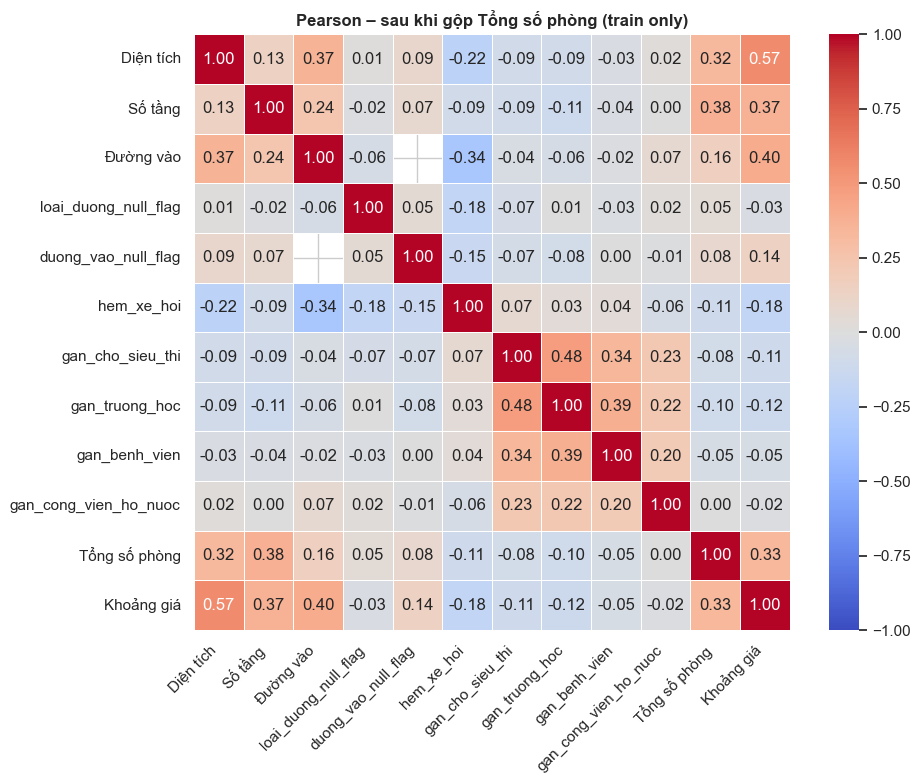

Tương quan Tổng số phòng ↔ Khoảng giá: 0.331


In [40]:
# 1. Ép kiểu y_train (cột Khoảng giá từ Qwen) về dạng số (float)
y_train = pd.to_numeric(y_train, errors='coerce')

# 2. Gộp và lọc (lúc này y_train đã là số nên sẽ không bị loại bỏ nữa)
train_num = pd.concat([X_train, y_train], axis=1).select_dtypes(include='number')

# 3. Tính ma trận tương quan
corr = train_num.drop(columns=['Longitude', 'Latitude'], errors='ignore').corr()

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.4)
plt.title('Pearson – sau khi gộp Tổng số phòng (train only)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. In kết quả (lúc này corr chắc chắn đã có cột 'Khoảng giá')
print('Tương quan Tổng số phòng ↔ Khoảng giá:', round(corr.loc[ROOM_COL, 'Khoảng giá'], 3))

## 3.3.3 Mã hoá biến categorical

| Cột | Phương pháp | Lý do |
|---|---|---|
| `Pháp lý`, `Nội thất` | One-Hot Encoding (drop first) | Không có thứ tự rõ ràng, số nhóm ít |
| `Loại đường vào` | Ordinal Encoding | Có thứ bậc: Mặt tiền > Hẻm ô tô > Hẻm xe máy > Chưa xác định |

> **Quy tắc:** `ohe` và `ordinal_enc` được `.fit` trên **train**, chỉ `.transform` trên **test**.


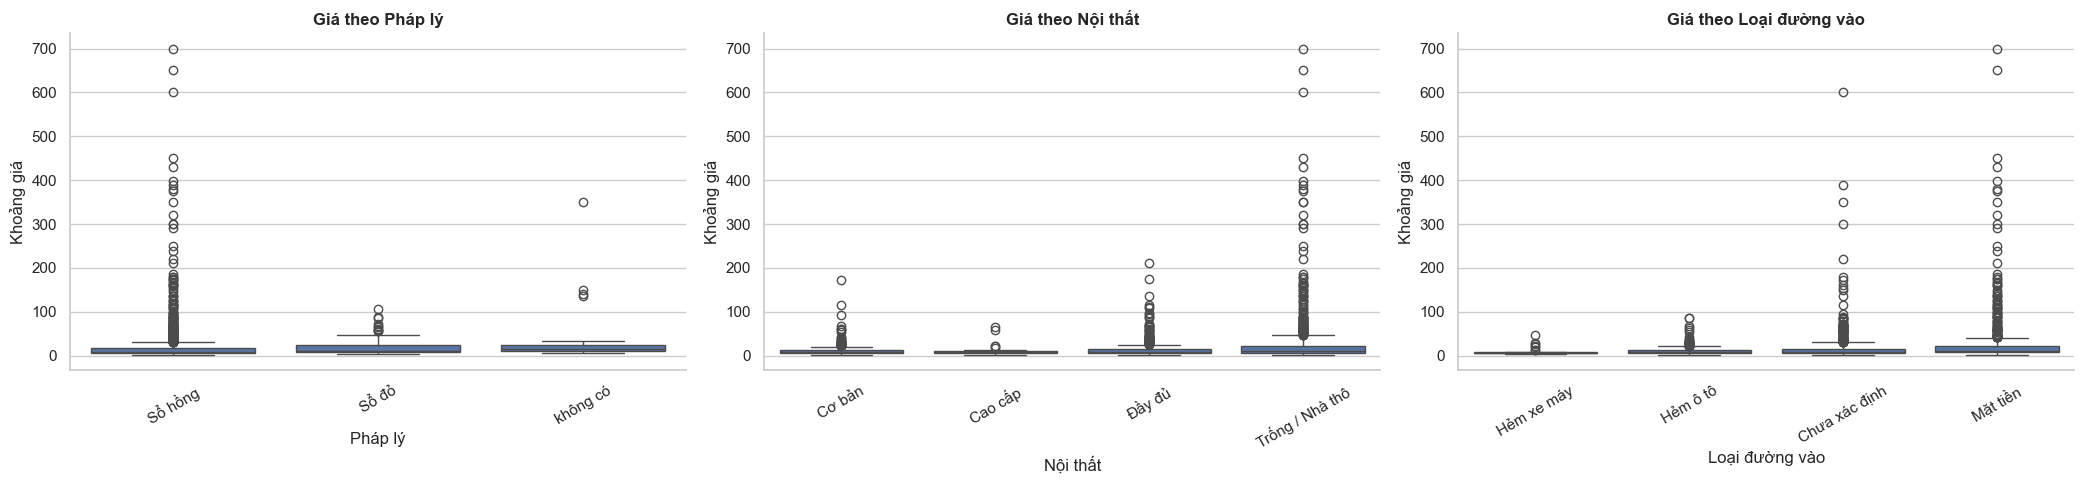

In [41]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

CAT_COLS = ['Pháp lý', 'Nội thất', 'Loại đường vào']
existing_cat = [c for c in CAT_COLS if c in X_train.columns]

if existing_cat:
    fig, axes = plt.subplots(1, len(existing_cat), figsize=(7 * len(existing_cat), 5))
    if len(existing_cat) == 1:
        axes = [axes]
    tmp = pd.concat([X_train[existing_cat], y_train], axis=1)
    for ax, col in zip(axes, existing_cat):
        order = tmp.groupby(col, observed=False)['Khoảng giá'].median().sort_values().index
        sns.boxplot(data=tmp, x=col, y='Khoảng giá', order=order, ax=ax)
        ax.set_title(f'Giá theo {col}', fontweight='bold')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()


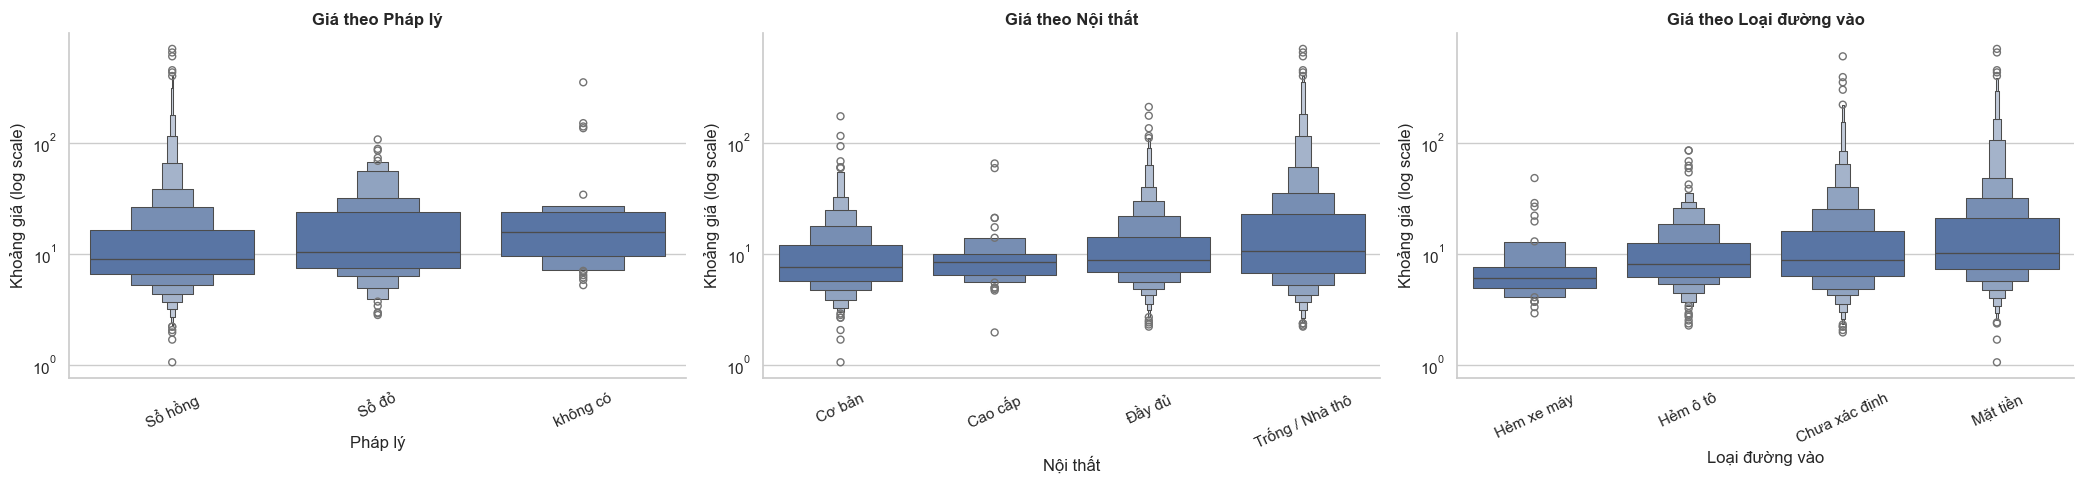

In [42]:

CAT_COLS = ['Pháp lý', 'Nội thất', 'Loại đường vào']

existing_cat = [c for c in CAT_COLS if c in X_train.columns]

if existing_cat:


    tmp = pd.concat(
        [
            X_train[existing_cat].copy(),
            y_train.copy()
        ],
        axis=1
    )


    fig, axes = plt.subplots(
        1,
        len(existing_cat),
        figsize=(7 * len(existing_cat), 5)
    )

    if len(existing_cat) == 1:
        axes = [axes]

    for ax, col in zip(axes, existing_cat):

        order = (
            tmp.groupby(col, observed=False)['Khoảng giá']
            .median()
            .sort_values()
            .index
        )

        sns.boxenplot(
            data=tmp,
            x=col,
            y='Khoảng giá',
            order=order,
            ax=ax
        )

        ax.set_yscale('log')

        ax.set_title(
            f'Giá theo {col}',
            fontweight='bold',
            fontsize=12
        )

        ax.set_xlabel(col)
        ax.set_ylabel('Khoảng giá (log scale)')

        ax.tick_params(
            axis='x',
            rotation=25
        )

    plt.tight_layout()
    plt.show()

else:
    print("Không tìm thấy categorical columns phù hợp.")

In [43]:
OHE_COLS = [c for c in ['Pháp lý', 'Nội thất'] if c in X_train.columns]

if OHE_COLS:
    for col in OHE_COLS:
        X_train[col].fillna('Không xác định', inplace=True)
        X_test[col].fillna('Không xác định', inplace=True)

    try:
        ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
    except TypeError:
        ohe = OneHotEncoder(sparse=False, drop='first', handle_unknown='ignore')

    train_ohe_arr = ohe.fit_transform(X_train[OHE_COLS])
    test_ohe_arr  = ohe.transform(X_test[OHE_COLS])
    ohe_names = ohe.get_feature_names_out(OHE_COLS)

    X_train = pd.concat(
        [X_train.drop(columns=OHE_COLS),
         pd.DataFrame(train_ohe_arr, columns=ohe_names, index=X_train.index)],
        axis=1
    )
    X_test = pd.concat(
        [X_test.drop(columns=OHE_COLS),
         pd.DataFrame(test_ohe_arr, columns=ohe_names, index=X_test.index)],
        axis=1
    )
    print(f'✅ OHE xong: {list(ohe_names)}')
else:
    print('ℹ️  Không tìm thấy cột Pháp lý / Nội thất.')

checkpoint('3.3.2 – sau OHE')


✅ OHE xong: ['Pháp lý_Sổ đỏ', 'Pháp lý_không có', 'Nội thất_Cơ bản', 'Nội thất_Trống / Nhà thô', 'Nội thất_Đầy đủ']

───────────────────────────────────────────────────────
[CHECKPOINT] 3.3.2 – sau OHE
  X_train : (2823, 25)  | X_test : (677, 25)
  y_train : (2823,)  | y_test : (677,)
           null_train  null_test
Đường vào         954        230
Đường             152         34
───────────────────────────────────────────────────────


In [44]:
if 'Loại đường vào' in X_train.columns:
    for df_ in [X_train, X_test]:
        df_['Loại đường vào'].fillna('Chưa xác định', inplace=True)

    ORDINAL_ORDER = [['Chưa xác định', 'Hẻm xe máy', 'Hẻm ô tô', 'Mặt tiền']]
    ordinal_enc = OrdinalEncoder(
        categories=ORDINAL_ORDER,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )
    X_train[['Loại đường vào']] = ordinal_enc.fit_transform(X_train[['Loại đường vào']])
    X_test[['Loại đường vào']]  = ordinal_enc.transform(X_test[['Loại đường vào']])
    print('✅ Ordinal encoding xong: Loại đường vào')
else:
    print('ℹ️  Không tìm thấy cột Loại đường vào.')

checkpoint('3.3.3 – sau Ordinal Encoding')


✅ Ordinal encoding xong: Loại đường vào

───────────────────────────────────────────────────────
[CHECKPOINT] 3.3.3 – sau Ordinal Encoding
  X_train : (2823, 25)  | X_test : (677, 25)
  y_train : (2823,)  | y_test : (677,)
           null_train  null_test
Đường vào         954        230
Đường             152         34
───────────────────────────────────────────────────────


In [45]:

area_stats_train = X_train['Diện tích'].describe()
area_stats_test  = X_test['Diện tích'].describe()

print("Train Diện tích:", area_stats_train[['mean','std','min','max']].round(1).to_dict())
print("Test  Diện tích:", area_stats_test[['mean','std','min','max']].round(1).to_dict())

outlier_dt_in_train = (X_train['Diện tích'] > 500).sum()
outlier_dt_in_test  = (X_test['Diện tích']  > 500).sum()
print(f"Outlier Diện tích >500m² còn sót: train={outlier_dt_in_train}, test={outlier_dt_in_test}")

Train Diện tích: {'mean': 87.1, 'std': 75.7, 'min': 1.1, 'max': 943.0}
Test  Diện tích: {'mean': 85.5, 'std': 71.8, 'min': 1.0, 'max': 715.0}
Outlier Diện tích >500m² còn sót: train=15, test=5


In [46]:

QUAN_COL = 'Quận'

if QUAN_COL in X_train.columns:
    # 1. Tính mean target trên train
    quan_mean = (
        pd.concat([X_train[[QUAN_COL]], y_train], axis=1)
        .groupby(QUAN_COL)[y_train.name]
        .mean()
    )

    # 2. Smoothing để tránh overfit với quận ít mẫu
    # công thức: (n_i * mean_i + m * global_mean) / (n_i + m)
    # m = 10: quận nào < 10 mẫu thì bị kéo về global mean
    global_mean = y_train.mean()
    quan_count  = X_train[QUAN_COL].value_counts()
    m = 10

    quan_smooth = (
        (quan_count * quan_mean + m * global_mean) / (quan_count + m)
    )

    # 3. Map vào train và test
    X_train['Quận_encoded'] = X_train[QUAN_COL].map(quan_smooth)
    X_test['Quận_encoded']  = X_test[QUAN_COL].map(quan_smooth)

    # 4. Xử lý quận lạ trong test không có trong train → điền global mean
    X_test['Quận_encoded'] = X_test['Quận_encoded'].fillna(global_mean)

    # 5. Xoá cột gốc
    X_train.drop(columns=[QUAN_COL], inplace=True)
    X_test.drop(columns=[QUAN_COL], inplace=True)

    # 6. Kiểm tra
    print(f"✅ Target encoding Quận xong")
    print(f"   Top 5 quận theo giá trung bình:")
    print(quan_smooth.sort_values(ascending=False).head(5).round(2).to_string())
    print(f"\n   Null train: {X_train['Quận_encoded'].isna().sum()}")
    print(f"   Null test : {X_test['Quận_encoded'].isna().sum()}")

    checkpoint('3.4 – sau Target Encoding Quận')

else:
    print(f"⚠️ Không tìm thấy cột '{QUAN_COL}' trong X_train")

✅ Target encoding Quận xong
   Top 5 quận theo giá trung bình:
Quận
3            46.42
1            44.69
2            24.61
10           22.79
Phú Nhuận    18.78

   Null train: 0
   Null test : 0

───────────────────────────────────────────────────────
[CHECKPOINT] 3.4 – sau Target Encoding Quận
  X_train : (2823, 25)  | X_test : (677, 25)
  y_train : (2823,)  | y_test : (677,)
           null_train  null_test
Đường vào         954        230
Đường             152         34
───────────────────────────────────────────────────────


## LƯU CÁC TẬP DỮ LIỆU ĐÃ XỬ LÝ RA FILE CSV

In [47]:
from pathlib import Path

output_dir = Path.cwd().parent.parent / "data" / "Processed" / "Processed_data"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"⏳ Đang tiến hành lưu các tập dữ liệu vào: {output_dir} ...")

datasets = {
    'X_train_processed.csv': X_train,
    'y_train_processed.csv': y_train,
    'X_test_processed.csv': X_test,
    'y_test_processed.csv': y_test
}

for file_name, data in datasets.items():
    try:
        if isinstance(data, pd.Series):
            data_to_save = data.to_frame()
        else:
            data_to_save = data

        full_path = output_dir / file_name
        data_to_save.to_csv(full_path, index=True)
        print(f"✅ Đã lưu: {file_name:<23} | Kích thước: {data_to_save.shape}")
    except Exception as e:
        print(f"❌ Gặp lỗi khi lưu file {file_name}: {e}")

print(f"\n🎉 Hoàn tất! Tất cả các file đã được lưu tại: {output_dir}")

⏳ Đang tiến hành lưu các tập dữ liệu vào: c:\Users\ADMIN\Tien_xu_ly_du_lieu_BDS\data\Processed\Processed_data ...
✅ Đã lưu: X_train_processed.csv   | Kích thước: (2823, 25)
✅ Đã lưu: y_train_processed.csv   | Kích thước: (2823, 1)
✅ Đã lưu: X_test_processed.csv    | Kích thước: (677, 25)
✅ Đã lưu: y_test_processed.csv    | Kích thước: (677, 1)

🎉 Hoàn tất! Tất cả các file đã được lưu tại: c:\Users\ADMIN\Tien_xu_ly_du_lieu_BDS\data\Processed\Processed_data
